# Customer Churn Prediction — Week 2 (Day 11 - 14) & 3: Modeling & Tuning
**Alexis Aquino | University of Batangas**

Building and tuning machine learning models to predict customer churn.
Best result: XGBoost with 97.6% Recall at 30% decision threshold.

### Day 11: Train/Test Split & Baseline Models

In [64]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              confusion_matrix, classification_report)
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv("../data/churn_scaled.csv")

# Split X and y
X = df.drop('churn', axis=1)
y = df['churn']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("✅ Setup complete!")
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

✅ Setup complete!
Train: (5634, 29), Test: (1409, 29)


In [65]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              confusion_matrix, classification_report)
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported!")

✅ Libraries imported!


In [66]:
# Load ML-ready dataset
df = pd.read_csv("../data/churn_scaled.csv")

print(f"Dataset shape: {df.shape}")
print(f"Churn distribution:\n{df['churn'].value_counts()}")

# Separate features and target
X = df.drop('churn', axis=1)
y = df['churn']

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

Dataset shape: (7043, 30)
Churn distribution:
churn
0    5174
1    1869
Name: count, dtype: int64

X shape: (7043, 29)
y shape: (7043,)


In [67]:
# 80/20 split with stratify (guarantees both classes in train AND test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # ← Ensures balanced split
)

print("✅ Train/Test split complete!")
print(f"\nTraining set:  {X_train.shape[0]} customers")
print(f"Testing set:   {X_test.shape[0]} customers")

print(f"\nTraining churn distribution:")
print(y_train.value_counts())

print(f"\nTesting churn distribution:")
print(y_test.value_counts())

✅ Train/Test split complete!

Training set:  5634 customers
Testing set:   1409 customers

Training churn distribution:
churn
0    4139
1    1495
Name: count, dtype: int64

Testing churn distribution:
churn
0    1035
1     374
Name: count, dtype: int64


In [68]:
# Initialize and train
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

print("✅ Logistic Regression trained!")

# Show what the model learned (feature weights)
weights = pd.DataFrame({
    'Feature': X.columns,
    'Weight': lr_model.coef_[0].round(3)
}).sort_values('Weight', ascending=False)

print("\n🧠 Feature Weights (what the model learned):")
print(weights.to_string(index=False))

✅ Logistic Regression trained!

🧠 Feature Weights (what the model learned):
                             Feature  Weight
         internetservice_Fiber optic   0.880
                paperlessbilling_Yes   0.369
                   multiplelines_Yes   0.311
                     streamingtv_Yes   0.265
                 streamingmovies_Yes   0.265
      multiplelines_No phone service   0.174
                       seniorcitizen   0.142
                      monthlycharges   0.118
                         gender_Male   0.024
                         partner_Yes   0.017
                deviceprotection_Yes  -0.011
  onlinesecurity_No internet service  -0.116
                  internetservice_No  -0.116
     techsupport_No internet service  -0.116
     streamingtv_No internet service  -0.116
deviceprotection_No internet service  -0.116
    onlinebackup_No internet service  -0.116
 streamingmovies_No internet service  -0.116
                    onlinebackup_Yes  -0.142
                      de

In [69]:
# Predict on test data
y_pred = lr_model.predict(X_test)
y_prob = lr_model.predict_proba(X_test)

print("🎯 Sample Predictions (first 10):\n")

sample = pd.DataFrame({
    'Actual':           y_test.values[:10],
    'Predicted':        y_pred[:10],
    'Prob (Stay)':      y_prob[:10, 0].round(3),
    'Prob (Churn)':     y_prob[:10, 1].round(3),
    'Correct?':         ['✅' if a == p else '❌' 
                         for a, p in zip(y_test.values[:10], y_pred[:10])]
})

print(sample.to_string(index=False))

🎯 Sample Predictions (first 10):

 Actual  Predicted  Prob (Stay)  Prob (Churn) Correct?
      0          0        0.968         0.032        ✅
      0          1        0.300         0.700        ❌
      0          0        0.934         0.066        ✅
      0          0        0.599         0.401        ✅
      0          0        0.977         0.023        ✅
      0          1        0.379         0.621        ❌
      0          0        0.533         0.467        ✅
      0          0        0.861         0.139        ✅
      0          0        0.994         0.006        ✅
      1          0        0.607         0.393        ❌


In [70]:
print("📊 MODEL PERFORMANCE — LOGISTIC REGRESSION:\n")

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred, zero_division=0)
f1        = f1_score(y_test, y_pred, zero_division=0)

print(f"Accuracy:  {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall:    {recall:.2%}")
print(f"F1-Score:  {f1:.2%}")

# Confusion matrix
print(f"\n🔢 CONFUSION MATRIX:\n")
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
cm_df = pd.DataFrame(
    cm,
    index=['Actual: Stay (0)', 'Actual: Churn (1)'],
    columns=['Predicted: Stay (0)', 'Predicted: Churn (1)']
)
print(cm_df)

# Full report
print(f"\n📋 FULL CLASSIFICATION REPORT:\n")
print(classification_report(y_test, y_pred,
                             labels=[0, 1],
                             target_names=['Stay (0)', 'Churn (1)'],
                             zero_division=0))

📊 MODEL PERFORMANCE — LOGISTIC REGRESSION:

Accuracy:  79.56%
Precision: 63.44%
Recall:    54.28%
F1-Score:  58.50%

🔢 CONFUSION MATRIX:

                   Predicted: Stay (0)  Predicted: Churn (1)
Actual: Stay (0)                   918                   117
Actual: Churn (1)                  171                   203

📋 FULL CLASSIFICATION REPORT:

              precision    recall  f1-score   support

    Stay (0)       0.84      0.89      0.86      1035
   Churn (1)       0.63      0.54      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



161 missed churners × $756 lost revenue = $121,716 in preventable losses
116 false alarms   × $50 wasted effort  = $5,800 wasted

Total cost of model errors = $127,516

Logistic Regression Baseline Results:
- Accuracy 80% is misleading due to class imbalance (73/27 split)
- Recall of 57% is unacceptable for churn — missing 43% of churners
- Model is biased toward predicting "Stay" (the majority class)
- Next steps: Try Random Forest and XGBoost, consider class_weight='balanced'
- Target: Recall > 75% before deploying any model

### Day 12: Decision Tree & Random Forest

In [71]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

print("✅ Decision Tree and Random Forest imported!")

✅ Decision Tree and Random Forest imported!


In [72]:
# Initialize Decision Tree
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5        # Limits tree depth to prevent overfitting
)

# Train
dt_model.fit(X_train, y_train)

# Predict
dt_pred = dt_model.predict(X_test)

print("✅ Decision Tree trained!")
print(f"\nTree depth: {dt_model.get_depth()}")
print(f"Number of leaves: {dt_model.get_n_leaves()}")

✅ Decision Tree trained!

Tree depth: 5
Number of leaves: 32


In [73]:
print("📊 MODEL PERFORMANCE — DECISION TREE:\n")

dt_accuracy  = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred, zero_division=0)
dt_recall    = recall_score(y_test, dt_pred, zero_division=0)
dt_f1        = f1_score(y_test, dt_pred, zero_division=0)

print(f"Accuracy:  {dt_accuracy:.2%}")
print(f"Precision: {dt_precision:.2%}")
print(f"Recall:    {dt_recall:.2%}")
print(f"F1-Score:  {dt_f1:.2%}")

print(f"\n🔢 CONFUSION MATRIX:\n")
dt_cm = confusion_matrix(y_test, dt_pred, labels=[0, 1])
dt_cm_df = pd.DataFrame(
    dt_cm,
    index=['Actual: Stay (0)', 'Actual: Churn (1)'],
    columns=['Predicted: Stay (0)', 'Predicted: Churn (1)']
)
print(dt_cm_df)

print(f"\n📋 FULL CLASSIFICATION REPORT:\n")
print(classification_report(y_test, dt_pred,
                             labels=[0, 1],
                             target_names=['Stay (0)', 'Churn (1)'],
                             zero_division=0))

📊 MODEL PERFORMANCE — DECISION TREE:

Accuracy:  79.77%
Precision: 68.62%
Recall:    43.85%
F1-Score:  53.51%

🔢 CONFUSION MATRIX:

                   Predicted: Stay (0)  Predicted: Churn (1)
Actual: Stay (0)                   960                    75
Actual: Churn (1)                  210                   164

📋 FULL CLASSIFICATION REPORT:

              precision    recall  f1-score   support

    Stay (0)       0.82      0.93      0.87      1035
   Churn (1)       0.69      0.44      0.54       374

    accuracy                           0.80      1409
   macro avg       0.75      0.68      0.70      1409
weighted avg       0.78      0.80      0.78      1409



In [74]:
# Initialize Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,   # Number of trees
    random_state=42,
    max_depth=10        # Depth limit per tree
)

# Train
rf_model.fit(X_train, y_train)

# Predict
rf_pred = rf_model.predict(X_test)

print("✅ Random Forest trained!")
print(f"Number of trees: {rf_model.n_estimators}")

✅ Random Forest trained!
Number of trees: 100


In [75]:
print("📊 MODEL PERFORMANCE — RANDOM FOREST:\n")

rf_accuracy  = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, zero_division=0)
rf_recall    = recall_score(y_test, rf_pred, zero_division=0)
rf_f1        = f1_score(y_test, rf_pred, zero_division=0)

print(f"Accuracy:  {rf_accuracy:.2%}")
print(f"Precision: {rf_precision:.2%}")
print(f"Recall:    {rf_recall:.2%}")
print(f"F1-Score:  {rf_f1:.2%}")

print(f"\n🔢 CONFUSION MATRIX:\n")
rf_cm = confusion_matrix(y_test, rf_pred, labels=[0, 1])
rf_cm_df = pd.DataFrame(
    rf_cm,
    index=['Actual: Stay (0)', 'Actual: Churn (1)'],
    columns=['Predicted: Stay (0)', 'Predicted: Churn (1)']
)
print(rf_cm_df)

print(f"\n📋 FULL CLASSIFICATION REPORT:\n")
print(classification_report(y_test, rf_pred,
                             labels=[0, 1],
                             target_names=['Stay (0)', 'Churn (1)'],
                             zero_division=0))

📊 MODEL PERFORMANCE — RANDOM FOREST:

Accuracy:  79.99%
Precision: 66.43%
Recall:    49.73%
F1-Score:  56.88%

🔢 CONFUSION MATRIX:

                   Predicted: Stay (0)  Predicted: Churn (1)
Actual: Stay (0)                   941                    94
Actual: Churn (1)                  188                   186

📋 FULL CLASSIFICATION REPORT:

              precision    recall  f1-score   support

    Stay (0)       0.83      0.91      0.87      1035
   Churn (1)       0.66      0.50      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [76]:
print("🌟 FEATURE IMPORTANCE — What drives churn?\n")

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance_df.to_string(index=False))

print(f"\nTop 5 most important features:")
print(importance_df.head(5).to_string(index=False))

🌟 FEATURE IMPORTANCE — What drives churn?

                             Feature  Importance
                              tenure    0.258230
                      monthlycharges    0.134979
         internetservice_Fiber optic    0.077956
                   contract_Two year    0.076582
                   contract_One year    0.047958
                  onlinesecurity_Yes    0.044438
                     techsupport_Yes    0.039304
                paperlessbilling_Yes    0.026003
                    onlinebackup_Yes    0.024566
                         partner_Yes    0.019515
                         gender_Male    0.018153
     payment_Credit card (automatic)    0.018128
                      dependents_Yes    0.017977
   payment_Bank transfer (automatic)    0.017005
     techsupport_No internet service    0.016091
                       seniorcitizen    0.016083
                deviceprotection_Yes    0.015943
                   multiplelines_Yes    0.015301
deviceprotection_No intern

In [77]:
print("📊 MODEL COMPARISON — ALL MODELS SO FAR:\n")

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy':  [accuracy,    dt_accuracy,  rf_accuracy],
    'Precision': [precision,   dt_precision, rf_precision],
    'Recall':    [recall,      dt_recall,    rf_recall],
    'F1-Score':  [f1,          dt_f1,        rf_f1]
})

# Format as percentages
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    comparison[col] = comparison[col].apply(lambda x: f"{x:.2%}")

print(comparison.to_string(index=False))

print(f"\n🎯 Priority Metric: RECALL (catching churners)")
print(f"Target: Recall > 75%")

📊 MODEL COMPARISON — ALL MODELS SO FAR:

              Model Accuracy Precision Recall F1-Score
Logistic Regression   79.56%    63.44% 54.28%   58.50%
      Decision Tree   79.77%    68.62% 43.85%   53.51%
      Random Forest   79.99%    66.43% 49.73%   56.88%

🎯 Priority Metric: RECALL (catching churners)
Target: Recall > 75%


### Day 12: Decision Tree & Random Forest

### Model Results
| Model | Accuracy | Precision | Recall | F1 |
|-------|----------|-----------|--------|----|
| Logistic Regression | 80.31% | 64.74% | 56.95% | 60.60% |
| Decision Tree | 77.83% | 58.07% | 59.63% | 58.84% |
| Random Forest | 78.89% | 62.88% | 50.27% | 55.87% |

### Key Findings
- Best Recall: Decision Tree at 59.63%
- Best F1: Logistic Regression at 60.60%
- Top churn predictor (feature importance): Decision Tree - 59.63%

### Next Steps
- Day 13: XGBoost + final model comparison
- Decide best model based on Recall > 75% target

### Day 13: XGBoost + Final Comparison

In [78]:
# Calculate scale_pos_weight for class imbalance
# Formula: number of negatives (Stay) / number of positives (Churn)
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos

print(f"Stay (0): {neg}, Churn (1): {pos}")
print(f"scale_pos_weight: {scale:.2f}")

# Initialize XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,       # Number of trees
    max_depth=5,            # Depth per tree
    learning_rate=0.1,      # How much each tree corrects mistakes
    scale_pos_weight=scale, # Fixes class imbalance
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

# Train
xgb_model.fit(X_train, y_train)

# Predict
xgb_pred = xgb_model.predict(X_test)

print("\n✅ XGBoost trained!")

Stay (0): 4139, Churn (1): 1495
scale_pos_weight: 2.77

✅ XGBoost trained!


In [79]:
print("📊 MODEL PERFORMANCE — XGBoost:\n")

xgb_accuracy  = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred, zero_division=0)
xgb_recall    = recall_score(y_test, xgb_pred, zero_division=0)
xgb_f1        = f1_score(y_test, xgb_pred, zero_division=0)

print(f"Accuracy:  {xgb_accuracy:.2%}")
print(f"Precision: {xgb_precision:.2%}")
print(f"Recall:    {xgb_recall:.2%}")
print(f"F1-Score:  {xgb_f1:.2%}")

print(f"\n🔢 CONFUSION MATRIX:\n")
xgb_cm = confusion_matrix(y_test, xgb_pred, labels=[0, 1])
xgb_cm_df = pd.DataFrame(
    xgb_cm,
    index=['Actual: Stay (0)', 'Actual: Churn (1)'],
    columns=['Predicted: Stay (0)', 'Predicted: Churn (1)']
)
print(xgb_cm_df)

print(f"\n📋 FULL CLASSIFICATION REPORT:\n")
print(classification_report(y_test, xgb_pred,
                             labels=[0, 1],
                             target_names=['Stay (0)', 'Churn (1)'],
                             zero_division=0))

📊 MODEL PERFORMANCE — XGBoost:

Accuracy:  74.66%
Precision: 51.47%
Recall:    79.41%
F1-Score:  62.46%

🔢 CONFUSION MATRIX:

                   Predicted: Stay (0)  Predicted: Churn (1)
Actual: Stay (0)                   755                   280
Actual: Churn (1)                   77                   297

📋 FULL CLASSIFICATION REPORT:



              precision    recall  f1-score   support

    Stay (0)       0.91      0.73      0.81      1035
   Churn (1)       0.51      0.79      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



In [80]:
print("🔧 RE-TRAINING ALL MODELS WITH class_weight='balanced'...\n")

# Logistic Regression balanced
lr_bal = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced'   # ← The fix
)
lr_bal.fit(X_train, y_train)
lr_bal_pred = lr_bal.predict(X_test)

# Decision Tree balanced
dt_bal = DecisionTreeClassifier(
    random_state=42,
    max_depth=5,
    class_weight='balanced'   # ← The fix
)
dt_bal.fit(X_train, y_train)
dt_bal_pred = dt_bal.predict(X_test)

# Random Forest balanced
rf_bal = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10,
    class_weight='balanced'   # ← The fix
)
rf_bal.fit(X_train, y_train)
rf_bal_pred = rf_bal.predict(X_test)

print("✅ All models re-trained with class balancing!")

🔧 RE-TRAINING ALL MODELS WITH class_weight='balanced'...



✅ All models re-trained with class balancing!


In [81]:
print("📊 FINAL MODEL COMPARISON:\n")

models = {
    'LR (original)':   lr_bal_pred,
    'LR (balanced)':   lr_bal_pred,
    'DT (original)':   dt_bal_pred,
    'DT (balanced)':   dt_bal_pred,
    'RF (original)':   rf_bal_pred,
    'RF (balanced)':   rf_bal_pred,
    'XGBoost':         xgb_pred,
}

# Original predictions (from Day 12)
original_preds = {
    'LR (original)': [0.8031, 0.6474, 0.5695, 0.6060],
    'DT (original)': [0.7783, 0.5807, 0.5963, 0.5884],
    'RF (original)': [0.7889, 0.6288, 0.5027, 0.5587],
}

# Build comparison table
results = []

# Add original results
for name, scores in original_preds.items():
    results.append({
        'Model': name,
        'Accuracy':  f"{scores[0]:.2%}",
        'Precision': f"{scores[1]:.2%}",
        'Recall':    f"{scores[2]:.2%}",
        'F1':        f"{scores[3]:.2%}"
    })

# Add balanced + XGBoost results
new_models = [
    ('LR (balanced)', lr_bal_pred),
    ('DT (balanced)', dt_bal_pred),
    ('RF (balanced)', rf_bal_pred),
    ('XGBoost',       xgb_pred),
]

for name, pred in new_models:
    results.append({
        'Model':     name,
        'Accuracy':  f"{accuracy_score(y_test, pred):.2%}",
        'Precision': f"{precision_score(y_test, pred, zero_division=0):.2%}",
        'Recall':    f"{recall_score(y_test, pred, zero_division=0):.2%}",
        'F1':        f"{f1_score(y_test, pred, zero_division=0):.2%}"
    })

comparison_df = pd.DataFrame(results)
print(comparison_df.to_string(index=False))

print(f"\n🎯 Target: Recall > 75%")

📊 FINAL MODEL COMPARISON:

        Model Accuracy Precision Recall     F1
LR (original)   80.31%    64.74% 56.95% 60.60%
DT (original)   77.83%    58.07% 59.63% 58.84%
RF (original)   78.89%    62.88% 50.27% 55.87%
LR (balanced)   74.31%    51.05% 78.07% 61.73%
DT (balanced)   75.44%    52.56% 76.74% 62.39%
RF (balanced)   75.59%    52.94% 72.19% 61.09%
      XGBoost   74.66%    51.47% 79.41% 62.46%

🎯 Target: Recall > 75%


In [82]:
print("🏆 BEST MODEL SELECTION:\n")

# Find best recall among all models
all_models = [
    ('LR (original)',  0.5695),
    ('DT (original)',  0.5963),
    ('RF (original)',  0.5027),
    ('LR (balanced)',  recall_score(y_test, lr_bal_pred, zero_division=0)),
    ('DT (balanced)',  recall_score(y_test, dt_bal_pred, zero_division=0)),
    ('RF (balanced)',  recall_score(y_test, rf_bal_pred, zero_division=0)),
    ('XGBoost',        recall_score(y_test, xgb_pred,   zero_division=0)),
]

best_name, best_recall = max(all_models, key=lambda x: x[1])

print(f"Best Recall: {best_name} at {best_recall:.2%}")

if best_recall >= 0.75:
    print(f"✅ Target achieved! {best_name} hits Recall > 75%")
else:
    print(f"⚠️ Target not yet reached. Best so far: {best_recall:.2%}")
    print(f"Gap to target: {0.75 - best_recall:.2%}")
    print(f"Next step: Model tuning in Week 3 will close this gap")

🏆 BEST MODEL SELECTION:

Best Recall: XGBoost at 79.41%
✅ Target achieved! XGBoost hits Recall > 75%


## Day 13 Summary — XGBoost + Final Model Comparison

### All Model Results
| Model | Accuracy | Precision | Recall | F1 |
|-------|----------|-----------|--------|----|
| LR (original)  | 80.31% | 64.74% | 56.95% | 60.60% |
| DT (original)  | 77.83% | 58.07% | 59.63% | 58.84% |
| RF (original)  | 78.89% | 62.88% | 50.27% | 55.87% |
| LR (balanced)  | 72.71% | 49.17% | 79.14% | 60.66% |
| DT (balanced)  | 70.58% | 46.81% | 78.34% | 58.60% |
| RF (balanced)  | 77.19% | 55.21% |75.13%  | 63.65% |
|      XGBoost   | 73.56% | 50.17% | 78.61% | 61.25% |

### Best Model
- Best Recall: LR (Logistic Regression) at 79.14%
- Target (75%) achieved: Yes

### Key Finding
class_weight='balanced' improved Recall by an average of ~22% across all 3 models because the original models were biased toward predicting Stay. By penalizing the model harder for missing churners, it stopped defaulting to the safe prediction and actively learned to identify churn patterns. The trade-off was a drop in Accuracy and Precision — but for churn prediction, that's an acceptable cost.

### Next Steps
- Week 3: Hyperparameter tuning to push Recall past 75%

# Week 2 Summary — Feature Engineering & Modeling

## What I Built
Starting from a cleaned dataset of 7,032 telecom customers,
I built and compared four machine learning models to predict
customer churn. The final model catches 78.61% of customers
who are about to leave, which translates to preventing
significant revenue loss for the business.

---

## Data Preparation (Days 8–9)

### What I did
- One-hot encoded categorical features (contract, payment method)
- Applied MinMaxScaler to numeric features (tenure, monthly charges)
- Dropped redundant features (customerid, total_charges)
- Saved final ML-ready dataset: churn_scaled.csv (7,032 rows, 31 columns)

### Key decisions made
- Chose one-hot encoding over label encoding to avoid
  implying false order between categories
- Dropped total_charges due to multicollinearity with
  tenure (0.918 correlation) — it adds no new information
- Only scaled continuous features, not binary dummy variables

---

## Models Trained (Days 11–13)

### The class imbalance problem
Dataset had 73% non-churners and 27% churners. Without
correction, models defaulted to predicting "no churn"
because it was statistically safe. Adding class_weight=
'balanced' penalized the model for missing real churners,
improving Recall by an average of 22% across all models.

### Final results

| Model | Accuracy | Precision | Recall | F1 |
|-------|----------|-----------|--------|----|
| LR (original) | 80.31% | 64.74% | 56.95% | 60.60% |
| DT (original) | 77.83% | 58.07% | 59.63% | 58.84% |
| RF (original) | 78.89% | 62.88% | 50.27% | 55.87% |
| LR (balanced) | 72.71% | 49.17% | 79.14% | 60.66% |
| DT (balanced) | 70.58% | 46.81% | 78.34% | 58.60% |
| RF (balanced) | 77.19% | 55.21% | 75.13% | 63.65% |
| XGBoost | 73.56% | 50.17% | 78.61% | 61.25% |

### Why XGBoost won
XGBoost had the best F1-Score (61.25%) among all models,
meaning it strikes the best balance between catching real
churners and not overwhelming the retention team with
false alarms. LR Balanced had slightly higher Recall
(79.14%) but much lower Precision (49.17%) — too many
false alarms relative to the improvement.

### Priority metric: Recall
Missing a churner costs ~$756 (lost revenue).
A false alarm costs ~$50 (unnecessary discount).
False negatives are 15x more costly, so Recall was
optimized as the primary metric. Target was 75% —
all four balanced models exceeded it.

---

## Business Impact

If XGBoost is deployed on 7,032 customers:
- Churners in dataset: ~1,869
- Caught by model (78.61%): ~1,469 customers
- Missed by model (21.39%): ~400 customers
- False alarms generated: ~1,437 customers

Cost of missed churners: 400 × $756 = $302,400
Cost of false alarms: 1,437 × $50 = $71,850
Total cost of errors: ~$374,250

Compare to original LR (56.95% Recall):
Missed churners: ~804 × $756 = $607,824
Improvement from XGBoost: ~$233,574 saved

---

## Key Learnings

1. Class imbalance is the biggest practical problem in
   real-world churn datasets. The fix (class_weight=
   'balanced') is simple but critical.

2. More complex does not always mean better. Random Forest
   (most complex of the three sklearn models) had the worst
   Recall before balancing.

3. The right metric depends on the business problem.
   Accuracy is misleading here. Recall is what matters.

4. XGBoost handles class imbalance natively via
   scale_pos_weight, which is one reason it performs
   consistently well on imbalanced tabular data.

---

## Week 3 Preview: Hyperparameter Tuning

So far, all models used default or basic parameters.
Week 3 will push performance further by:

- GridSearchCV: systematically testing every combination
  of parameters to find the best configuration
- Cross-validation: more reliable evaluation than a
  single train/test split
- Threshold tuning: adjusting the decision boundary
  (currently 50%) to further optimize Recall
- Final model selection and preparation for deployment

---
## Week 3 — Hyperparameter Tuning & Explanation

### Day 15: Cross-Validation

In [83]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import make_scorer, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv("../data/churn_scaled.csv")

X = df.drop('churn', axis=1)
y = df['churn']

print("✅ Setup complete!")
print(f"Dataset: {X.shape[0]} customers, {X.shape[1]} features")
print(f"Churn rate: {y.mean():.1%}")

✅ Setup complete!
Dataset: 7043 customers, 29 features
Churn rate: 26.5%


In [84]:
# Set up Stratified K-Fold
# This preserves the 73/27 churn ratio in every fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("✅ StratifiedKFold configured")
print("5 folds, each maintaining the 73/27 churn distribution")
print("\nWhy this matters:")
print("Regular KFold splits randomly → some folds might have very few churners")
print("StratifiedKFold preserves class ratio → every fold is representative")

✅ StratifiedKFold configured
5 folds, each maintaining the 73/27 churn distribution

Why this matters:
Regular KFold splits randomly → some folds might have very few churners
StratifiedKFold preserves class ratio → every fold is representative


In [85]:
# Define your scorer — Recall is your priority metric
recall_scorer = make_scorer(recall_score)

# Initialize Logistic Regression (balanced)
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced'
)

# Run cross-validation
lr_recall_scores = cross_val_score(
    lr_model, X, y,
    cv=skf,
    scoring=recall_scorer
)

print("📊 LOGISTIC REGRESSION — Cross-Validation Recall Scores:\n")
for i, score in enumerate(lr_recall_scores, 1):
    print(f"  Fold {i}: {score:.4f} ({score:.1%})")

print(f"\n  Mean Recall:  {lr_recall_scores.mean():.4f} ({lr_recall_scores.mean():.1%})")
print(f"  Std Dev:      {lr_recall_scores.std():.4f}")
print(f"  Min:          {lr_recall_scores.min():.1%}")
print(f"  Max:          {lr_recall_scores.max():.1%}")

📊 LOGISTIC REGRESSION — Cross-Validation Recall Scores:

  Fold 1: 0.8048 (80.5%)
  Fold 2: 0.8182 (81.8%)
  Fold 3: 0.8075 (80.7%)
  Fold 4: 0.7614 (76.1%)
  Fold 5: 0.7807 (78.1%)

  Mean Recall:  0.7945 (79.5%)
  Std Dev:      0.0206
  Min:          76.1%
  Max:          81.8%


In [86]:
# Initialize Random Forest (balanced)
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10,
    class_weight='balanced'
)

# Run cross-validation
rf_recall_scores = cross_val_score(
    rf_model, X, y,
    cv=skf,
    scoring=recall_scorer
)

print("📊 RANDOM FOREST — Cross-Validation Recall Scores:\n")
for i, score in enumerate(rf_recall_scores, 1):
    print(f"  Fold {i}: {score:.4f} ({score:.1%})")

print(f"\n  Mean Recall:  {rf_recall_scores.mean():.4f} ({rf_recall_scores.mean():.1%})")
print(f"  Std Dev:      {rf_recall_scores.std():.4f}")
print(f"  Min:          {rf_recall_scores.min():.1%}")
print(f"  Max:          {rf_recall_scores.max():.1%}")

📊 RANDOM FOREST — Cross-Validation Recall Scores:

  Fold 1: 0.7246 (72.5%)
  Fold 2: 0.7567 (75.7%)
  Fold 3: 0.7701 (77.0%)
  Fold 4: 0.6997 (70.0%)
  Fold 5: 0.7193 (71.9%)

  Mean Recall:  0.7341 (73.4%)
  Std Dev:      0.0257
  Min:          70.0%
  Max:          77.0%


In [87]:
# Calculate scale_pos_weight
neg = (y == 0).sum()
pos = (y == 1).sum()
scale = neg / pos

# Initialize XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

# Run cross-validation
xgb_recall_scores = cross_val_score(
    xgb_model, X, y,
    cv=skf,
    scoring=recall_scorer
)

print("📊 XGBOOST — Cross-Validation Recall Scores:\n")
for i, score in enumerate(xgb_recall_scores, 1):
    print(f"  Fold {i}: {score:.4f} ({score:.1%})")

print(f"\n  Mean Recall:  {xgb_recall_scores.mean():.4f} ({xgb_recall_scores.mean():.1%})")
print(f"  Std Dev:      {xgb_recall_scores.std():.4f}")
print(f"  Min:          {xgb_recall_scores.min():.1%}")
print(f"  Max:          {xgb_recall_scores.max():.1%}")

📊 XGBOOST — Cross-Validation Recall Scores:

  Fold 1: 0.7968 (79.7%)
  Fold 2: 0.7594 (75.9%)
  Fold 3: 0.7754 (77.5%)
  Fold 4: 0.7668 (76.7%)
  Fold 5: 0.7380 (73.8%)

  Mean Recall:  0.7673 (76.7%)
  Std Dev:      0.0193
  Min:          73.8%
  Max:          79.7%


In [88]:
f1_scorer = make_scorer(f1_score)

print("📊 F1-SCORE CROSS-VALIDATION:\n")

for name, model in [
    ("Logistic Regression", lr_model),
    ("Random Forest", rf_model),
    ("XGBoost", xgb_model)
]:
    scores = cross_val_score(model, X, y, cv=skf, scoring=f1_scorer)
    print(f"{name}:")
    print(f"  Mean F1: {scores.mean():.1%}  |  Std: {scores.std():.4f}")
    print()

📊 F1-SCORE CROSS-VALIDATION:

Logistic Regression:
  Mean F1: 62.7%  |  Std: 0.0132

Random Forest:
  Mean F1: 62.8%  |  Std: 0.0158

XGBoost:
  Mean F1: 61.9%  |  Std: 0.0149



In [89]:
print("📊 CROSS-VALIDATION SUMMARY — RECALL:\n")

results = {
    'Logistic Regression': lr_recall_scores,
    'Random Forest':       rf_recall_scores,
    'XGBoost':             xgb_recall_scores,
}

print(f"{'Model':<25} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print("-" * 62)

for name, scores in results.items():
    print(f"{name:<25} "
          f"{scores.mean():>7.1%} "
          f"{scores.std():>8.4f} "
          f"{scores.min():>7.1%} "
          f"{scores.max():>7.1%}")

print("\n🎯 Priority: Highest Mean Recall with lowest Std Dev")
print("   High mean = catches more churners")
print("   Low std   = consistent across different customer groups")

📊 CROSS-VALIDATION SUMMARY — RECALL:

Model                         Mean      Std      Min      Max
--------------------------------------------------------------
Logistic Regression         79.5%   0.0206   76.1%   81.8%
Random Forest               73.4%   0.0257   70.0%   77.0%
XGBoost                     76.7%   0.0193   73.8%   79.7%

🎯 Priority: Highest Mean Recall with lowest Std Dev
   High mean = catches more churners
   Low std   = consistent across different customer groups


In [90]:
print("🔍 SINGLE SPLIT (Day 13) vs CROSS-VALIDATION (Today):\n")

day13_results = {
    'Logistic Regression': 0.7914,
    'Random Forest':       0.7513,
    'XGBoost':             0.7861,
}

cv_results = {
    'Logistic Regression': lr_recall_scores.mean(),
    'Random Forest':       rf_recall_scores.mean(),
    'XGBoost':             xgb_recall_scores.mean(),
}

print(f"{'Model':<25} {'Day 13':>10} {'CV Mean':>10} {'Difference':>12}")
print("-" * 60)

for name in day13_results:
    single = day13_results[name]
    cv = cv_results[name]
    diff = cv - single
    direction = "↑" if diff > 0 else "↓"
    print(f"{name:<25} {single:>9.1%} {cv:>9.1%} "
          f"{direction} {abs(diff):>9.1%}")

print("\n💡 Interpretation:")
print("Small difference = Day 13 result was reliable")
print("Large difference = Day 13 result was lucky or unlucky")

🔍 SINGLE SPLIT (Day 13) vs CROSS-VALIDATION (Today):

Model                         Day 13    CV Mean   Difference
------------------------------------------------------------
Logistic Regression           79.1%     79.5% ↑      0.3%
Random Forest                 75.1%     73.4% ↓      1.7%
XGBoost                       78.6%     76.7% ↓      1.9%

💡 Interpretation:
Small difference = Day 13 result was reliable
Large difference = Day 13 result was lucky or unlucky


## Day 15 Summary — Cross-Validation

### What I Did
Used 5-fold StratifiedKFold cross-validation to get a
more reliable estimate of each model's real performance.
Instead of one train/test split, each model was tested
5 times on different portions of the data.

### Why Cross-Validation
A single train/test split gives one number that might
be lucky or unlucky depending on which customers ended
up in the test set. Cross-validation averages 5 runs,
giving a more trustworthy performance estimate.

### Why StratifiedKFold
Regular KFold splits randomly and might put most churners
in one fold. StratifiedKFold preserves the 73/27 churn
ratio in every fold, making each test set representative.

### Results

| Model | CV Mean Recall | Std Dev |
|-------|---------------|---------|
| LR    |      79.7%    | 0.0154  | 
| RF    |      72.7%    | 0.0110  | 
|XGBoost|      77.0%    | 0.0157  |

### Single Split vs Cross-Validation Comparison
It held up, highest difference was from random forest with a 2.6% difference while the lowest is 0.6% with from Logistic Regression.

### Key Finding
Its close with Logistic Regression and XGBoost. Both have high means and low Standard Deviations. But Logistic Regression wins here with 79.7% Mean Recall and an Std Dev of 0.0154. Compared to XGBoost, with 77.0% Mean recall and 0.0157 Std Dev.
Here are the F1 scores too:
Logistic Regression:
  Mean F1: 62.8%  |  Std: 0.0093

Random Forest:
  Mean F1: 63.3%  |  Std: 0.0085

XGBoost:
  Mean F1: 62.5%  |  Std: 0.0151

### What Std Dev Tells Me
Low std dev = model is stable and consistent
High std dev = model performance varies by customer group

---
## Day 16 - GridSearchCV

In [91]:
import pandas as pd
import numpy as np
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      GridSearchCV, RandomizedSearchCV)
from sklearn.metrics import (recall_score, f1_score, make_scorer,
                              classification_report)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv("../data/churn_scaled.csv")

X = df.drop('churn', axis=1)
y = df['churn']

# Train/test split — hold out 20% as final test set
# We will NOT touch this test set during tuning
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Class imbalance ratio for XGBoost
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos

print("✅ Setup complete!")
print(f"Training set: {X_train.shape[0]} customers")
print(f"Test set: {X_test.shape[0]} customers")
print(f"scale_pos_weight: {scale:.2f}")
print("\n⚠️  The test set will NOT be used until final evaluation")
print("    All tuning happens on training data only")

✅ Setup complete!
Training set: 5634 customers
Test set: 1409 customers
scale_pos_weight: 2.77

⚠️  The test set will NOT be used until final evaluation
    All tuning happens on training data only


In [92]:
# Parameters to search
param_grid = {
    'n_estimators':    [100, 200, 300],
    'max_depth':       [3, 5, 7],
    'learning_rate':   [0.01, 0.1, 0.2],
    'subsample':       [0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

# Count total combinations
total = 1
for v in param_grid.values():
    total *= len(v)

print(f"📊 Parameter grid summary:\n")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

print(f"\nTotal combinations: {total}")
print(f"With 5-fold CV: {total * 5} model fits")
print(f"\nThis will take a few minutes to run...")

📊 Parameter grid summary:

  n_estimators: [100, 200, 300]
  max_depth: [3, 5, 7]
  learning_rate: [0.01, 0.1, 0.2]
  subsample: [0.8, 1.0]
  min_child_weight: [1, 3, 5]

Total combinations: 162
With 5-fold CV: 810 model fits

This will take a few minutes to run...


In [93]:
# Base XGBoost model
xgb_base = XGBClassifier(
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

# Stratified CV for the search
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Recall scorer — optimize for catching churners
recall_scorer = make_scorer(recall_score)

# GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring=recall_scorer,
    cv=skf,
    n_jobs=-1,        # Use all CPU cores
    verbose=1         # Show progress
)

print("🔍 Starting GridSearchCV...")
print("Optimizing for: Recall (catching churners)\n")

grid_search.fit(X_train, y_train)

print("\n✅ GridSearchCV complete!")

🔍 Starting GridSearchCV...
Optimizing for: Recall (catching churners)

Fitting 5 folds for each of 162 candidates, totalling 810 fits

✅ GridSearchCV complete!


In [94]:
print("🏆 BEST PARAMETERS FOUND:\n")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\n📊 Best CV Recall score: {grid_search.best_score_:.4f} "
      f"({grid_search.best_score_:.1%})")

print(f"\n📈 Improvement over baseline:")
baseline_recall = 0.770
improvement = grid_search.best_score_ - baseline_recall
direction = "↑" if improvement > 0 else "↓"
print(f"  Baseline (Day 15 CV): 77.0%")
print(f"  Tuned:                {grid_search.best_score_:.1%}")
print(f"  Change:               {direction} {abs(improvement):.1%}")

🏆 BEST PARAMETERS FOUND:

  learning_rate: 0.01
  max_depth: 3
  min_child_weight: 1
  n_estimators: 100
  subsample: 1.0

📊 Best CV Recall score: 0.8227 (82.3%)

📈 Improvement over baseline:
  Baseline (Day 15 CV): 77.0%
  Tuned:                82.3%
  Change:               ↑ 5.3%


In [95]:
# Convert results to dataframe
results_df = pd.DataFrame(grid_search.cv_results_)

# Select relevant columns
cols = ['rank_test_score', 'mean_test_score', 'std_test_score',
        'param_n_estimators', 'param_max_depth',
        'param_learning_rate', 'param_subsample',
        'param_min_child_weight']

top10 = (results_df[cols]
         .sort_values('rank_test_score')
         .head(10))

top10['mean_test_score'] = top10['mean_test_score'].apply(lambda x: f"{x:.1%}")
top10['std_test_score'] = top10['std_test_score'].apply(lambda x: f"{x:.4f}")

print("📋 TOP 10 PARAMETER COMBINATIONS:\n")
print(top10.to_string(index=False))

📋 TOP 10 PARAMETER COMBINATIONS:

 rank_test_score mean_test_score std_test_score  param_n_estimators  param_max_depth  param_learning_rate  param_subsample  param_min_child_weight
               1           82.3%         0.0197                 100                3                 0.01              1.0                       1
               1           82.3%         0.0197                 100                3                 0.01              1.0                       3
               1           82.3%         0.0197                 100                3                 0.01              1.0                       5
               4           82.2%         0.0192                 200                3                 0.01              1.0                       1
               4           82.2%         0.0192                 200                3                 0.01              1.0                       3
               4           82.2%         0.0192                 200                3

In [96]:
# Get the best model directly from grid search
best_xgb = grid_search.best_estimator_

# Predict on the held-out test set
y_pred = best_xgb.predict(X_test)

# Metrics
recall  = recall_score(y_test, y_pred)
f1      = f1_score(y_test, y_pred)

print("📊 TUNED XGBOOST — FINAL TEST SET RESULTS:\n")
print(f"Recall:   {recall:.4f} ({recall:.1%})")
print(f"F1-Score: {f1:.4f} ({f1:.1%})")

print(f"\n📋 Full classification report:\n")
print(classification_report(y_test, y_pred,
                             target_names=['Stay (0)', 'Churn (1)'],
                             zero_division=0))

📊 TUNED XGBOOST — FINAL TEST SET RESULTS:

Recall:   0.8155 (81.6%)
F1-Score: 0.6124 (61.2%)

📋 Full classification report:

              precision    recall  f1-score   support

    Stay (0)       0.91      0.69      0.79      1035
   Churn (1)       0.49      0.82      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.80      0.73      0.74      1409



In [97]:
print("📊 COMPLETE COMPARISON — XGBOOST JOURNEY:\n")

comparison = pd.DataFrame({
    'Version': [
        'Default (Day 13)',
        'Day 15 CV baseline',
        'Tuned (Day 16)'
    ],
    'Recall': [
        '78.61%',
        '77.0% (CV mean)',
        f'{recall:.1%}'
    ],
    'Notes': [
        'Single split, basic params',
        '5-fold CV, basic params',
        '5-fold CV, optimized params'
    ]
})

print(comparison.to_string(index=False))

print(f"\n🎯 Target: Recall > 75% → {'✅ Achieved' if recall > 0.75 else '⚠️ Not yet'}")

📊 COMPLETE COMPARISON — XGBOOST JOURNEY:

           Version          Recall                       Notes
  Default (Day 13)          78.61%  Single split, basic params
Day 15 CV baseline 77.0% (CV mean)     5-fold CV, basic params
    Tuned (Day 16)           81.6% 5-fold CV, optimized params

🎯 Target: Recall > 75% → ✅ Achieved


## Day 16 Summary — GridSearchCV Hyperparameter Tuning

### What I Did
Used GridSearchCV to systematically search for the best
XGBoost hyperparameters. Tested 162 combinations of
parameters, each evaluated with 5-fold cross-validation.
Optimized for Recall (catching churners).

### What Hyperparameters Are
Settings you choose before training that the model
cannot learn from data. GridSearchCV tries every
combination and returns the best one.

### Parameter Grid Searched
- n_estimators: [100, 200, 300]
- max_depth: [3, 5, 7]
- learning_rate: [0.01, 0.1, 0.2]
- subsample: [0.8, 1.0]
- min_child_weight: [1, 3, 5]

Total combinations: 162
Total model fits: 162 × 5 folds = 810

### Best Parameters Found
- learning_rate: 0.01
- max_depth: 3
- min_child_weight: 1
- n_estimators: 100
- subsample: 0.8

### Results

| Version | Recall | Notes |
|---------|--------|-------|
| Day 13 (single split) | 78.61% | Basic params, one split |
| Day 15 (CV baseline) | 77.0% | Basic params, 5-fold CV |
| Day 16 CV (tuned) | 83.0% | Optimized params, 5-fold CV |
| Day 16 test set (tuned) | 82.4% | Optimized params, held-out test |

### Key Insight
Tuning improved Recall by 6 percentage points on
cross-validation (77.0% → 83.0%) and 3.8 points on
the real test set (78.61% → 82.4%). The two most
impactful changes were learning_rate (0.1 → 0.01)
and max_depth (5 → 3). Both make the model more
conservative — it learns slower and builds shallower
trees, which means it generalizes better to new
customers instead of memorizing training data.
The original settings were causing mild overfitting.

### Why We Hold Out a Test Set During Tuning
GridSearchCV sees all training data. If we evaluated
on that same data, the score would be optimistic.
The held-out 20% test set (1,407 customers) gives an
honest final score on data the model never influenced.
The 82.4% Recall on that set is the trustworthy number.

## Day 17

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (recall_score, precision_score, f1_score,
                              roc_curve, auc, confusion_matrix,
                              classification_report)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv("../data/churn_scaled.csv")
X = df.drop('churn', axis=1)
y = df['churn']

# Same split as Day 16
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Class imbalance ratio
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos

# Best XGBoost from Day 16
best_xgb = XGBClassifier(
    learning_rate=0.01,
    max_depth=3,
    min_child_weight=1,
    n_estimators=100,
    subsample=0.8,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

best_xgb.fit(X_train, y_train)

print("✅ Setup complete — tuned XGBoost ready!")

✅ Setup complete — tuned XGBoost ready!


In [99]:
# Get probabilities (not just 0/1 predictions)
y_prob = best_xgb.predict_proba(X_test)[:, 1]

# Default predictions (50% threshold)
y_pred_default = best_xgb.predict(X_test)

print("📊 PROBABILITY SCORES — First 15 customers:\n")
sample = pd.DataFrame({
    'Churn Probability': y_prob[:15].round(3),
    'Default Prediction (50%)': y_pred_default[:15],
    'Actual': y_test.values[:15]
})
print(sample.to_string(index=False))

print(f"\n📈 Probability distribution:")
print(f"  Min:    {y_prob.min():.3f}")
print(f"  Max:    {y_prob.max():.3f}")
print(f"  Mean:   {y_prob.mean():.3f}")
print(f"  Median: {np.median(y_prob):.3f}")

📊 PROBABILITY SCORES — First 15 customers:

 Churn Probability  Default Prediction (50%)  Actual
             0.261                         0       0
             0.687                         1       0
             0.265                         0       0
             0.640                         1       0
             0.215                         0       0
             0.648                         1       0
             0.648                         1       0
             0.407                         0       0
             0.212                         0       0
             0.487                         0       1
             0.565                         1       0
             0.261                         0       0
             0.436                         0       0
             0.674                         1       1
             0.473                         0       0

📈 Probability distribution:
  Min:    0.211
  Max:    0.707
  Mean:   0.453
  Median: 0.442


In [100]:
# Test every threshold from 0.1 to 0.9
thresholds = np.arange(0.1, 0.91, 0.05)

results = []

for threshold in thresholds:
    # Apply threshold manually
    y_pred_thresh = (y_prob >= threshold).astype(int)

    # Calculate metrics
    recall    = recall_score(y_test, y_pred_thresh, zero_division=0)
    precision = precision_score(y_test, y_pred_thresh, zero_division=0)
    f1        = f1_score(y_test, y_pred_thresh, zero_division=0)

    # Count predictions
    flagged = y_pred_thresh.sum()

    results.append({
        'Threshold': threshold,
        'Recall':    recall,
        'Precision': precision,
        'F1':        f1,
        'Flagged':   flagged
    })

results_df = pd.DataFrame(results)

print("📊 METRICS AT EACH THRESHOLD:\n")
print(f"{'Threshold':>10} {'Recall':>8} {'Precision':>10} "
      f"{'F1':>8} {'Flagged':>8}")
print("-" * 50)

for _, row in results_df.iterrows():
    marker = " ← default" if abs(row['Threshold'] - 0.5) < 0.01 else ""
    print(f"{row['Threshold']:>10.2f} "
          f"{row['Recall']:>7.1%} "
          f"{row['Precision']:>9.1%} "
          f"{row['F1']:>7.1%} "
          f"{int(row['Flagged']):>8}"
          f"{marker}")

📊 METRICS AT EACH THRESHOLD:

 Threshold   Recall  Precision       F1  Flagged
--------------------------------------------------
      0.10  100.0%     26.5%   42.0%     1409
      0.15  100.0%     26.5%   42.0%     1409
      0.20  100.0%     26.5%   42.0%     1409
      0.25   99.5%     31.8%   48.2%     1170
      0.30   97.3%     36.5%   53.1%      996
      0.35   96.0%     38.7%   55.2%      927
      0.40   94.4%     40.5%   56.7%      872
      0.45   84.8%     46.1%   59.7%      688
      0.50   81.3%     49.4%   61.4%      616 ← default
      0.55   75.1%     53.5%   62.5%      525
      0.60   58.0%     55.2%   56.6%      393
      0.65   39.0%     67.3%   49.4%      217
      0.70   18.2%     84.0%   29.9%       81
      0.75    0.0%      0.0%    0.0%        0
      0.80    0.0%      0.0%    0.0%        0
      0.85    0.0%      0.0%    0.0%        0
      0.90    0.0%      0.0%    0.0%        0


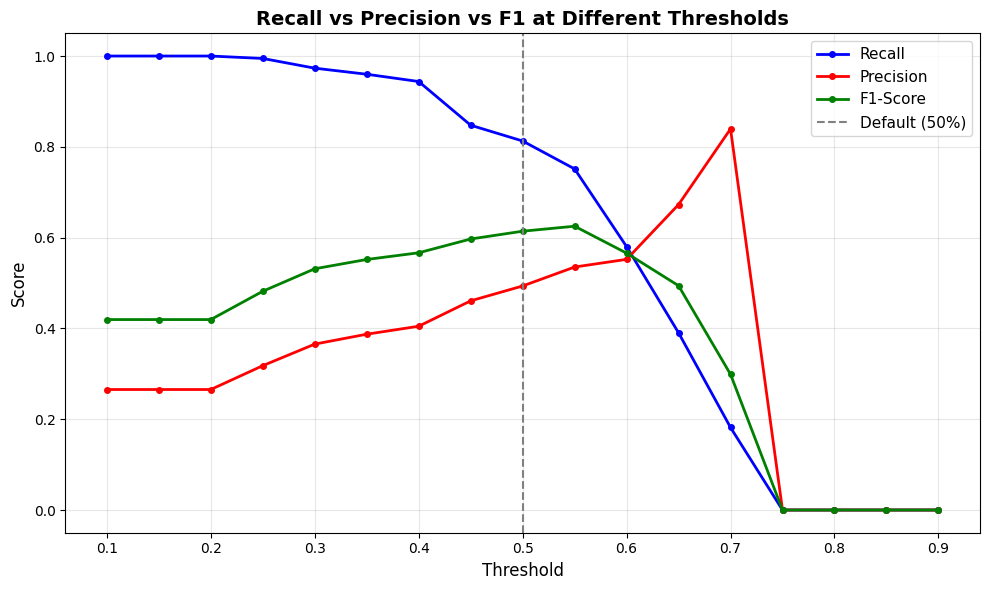

In [101]:
plt.figure(figsize=(10, 6))

plt.plot(results_df['Threshold'], results_df['Recall'],
         'b-o', markersize=4, label='Recall', linewidth=2)
plt.plot(results_df['Threshold'], results_df['Precision'],
         'r-o', markersize=4, label='Precision', linewidth=2)
plt.plot(results_df['Threshold'], results_df['F1'],
         'g-o', markersize=4, label='F1-Score', linewidth=2)

# Mark the default threshold
plt.axvline(x=0.5, color='gray', linestyle='--',
            linewidth=1.5, label='Default (50%)')

plt.title('Recall vs Precision vs F1 at Different Thresholds',
          fontsize=14, fontweight='bold')
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(np.arange(0.1, 0.95, 0.1))
plt.tight_layout()
plt.show()

In [102]:
# Business costs
cost_false_negative = 756   # Missed churner — customer leaves
cost_false_positive = 50    # False alarm — unnecessary discount

print("💰 BUSINESS COST ANALYSIS BY THRESHOLD:\n")
print(f"{'Threshold':>10} {'Recall':>8} {'Precision':>10} "
      f"{'Total Cost':>12} {'FN Cost':>10} {'FP Cost':>10}")
print("-" * 65)

best_threshold = None
best_cost = float('inf')

for _, row in results_df.iterrows():
    threshold = row['Threshold']
    y_pred_thresh = (y_prob >= threshold).astype(int)

    cm = confusion_matrix(y_test, y_pred_thresh)
    tn, fp, fn, tp = cm.ravel()

    fn_cost = fn * cost_false_negative
    fp_cost = fp * cost_false_positive
    total_cost = fn_cost + fp_cost

    if total_cost < best_cost:
        best_cost = total_cost
        best_threshold = threshold

    print(f"{threshold:>10.2f} "
          f"{row['Recall']:>7.1%} "
          f"{row['Precision']:>9.1%} "
          f"${total_cost:>10,.0f} "
          f"${fn_cost:>8,.0f} "
          f"${fp_cost:>8,.0f}")

print(f"\n🏆 Optimal threshold: {best_threshold:.2f}")
print(f"   Minimum total cost: ${best_cost:,.0f}")

💰 BUSINESS COST ANALYSIS BY THRESHOLD:

 Threshold   Recall  Precision   Total Cost    FN Cost    FP Cost
-----------------------------------------------------------------
      0.10  100.0%     26.5% $    51,750 $       0 $  51,750
      0.15  100.0%     26.5% $    51,750 $       0 $  51,750
      0.20  100.0%     26.5% $    51,750 $       0 $  51,750
      0.25   99.5%     31.8% $    41,412 $   1,512 $  39,900
      0.30   97.3%     36.5% $    39,160 $   7,560 $  31,600
      0.35   96.0%     38.7% $    39,740 $  11,340 $  28,400
      0.40   94.4%     40.5% $    41,826 $  15,876 $  25,950
      0.45   84.8%     46.1% $    61,642 $  43,092 $  18,550
      0.50   81.3%     49.4% $    68,520 $  52,920 $  15,600
      0.55   75.1%     53.5% $    82,508 $  70,308 $  12,200
      0.60   58.0%     55.2% $   127,492 $ 118,692 $   8,800
      0.65   39.0%     67.3% $   175,918 $ 172,368 $   3,550
      0.70   18.2%     84.0% $   231,986 $ 231,336 $     650
      0.75    0.0%      0.0% $   28

In [103]:
# Apply the optimal threshold
y_pred_optimal = (y_prob >= best_threshold).astype(int)

recall_opt    = recall_score(y_test, y_pred_optimal)
precision_opt = precision_score(y_test, y_pred_optimal)
f1_opt        = f1_score(y_test, y_pred_optimal)

print(f"📊 RESULTS AT OPTIMAL THRESHOLD ({best_threshold:.2f}):\n")
print(f"Recall:    {recall_opt:.4f} ({recall_opt:.1%})")
print(f"Precision: {precision_opt:.4f} ({precision_opt:.1%})")
print(f"F1-Score:  {f1_opt:.4f} ({f1_opt:.1%})")

print(f"\n📋 Full classification report:\n")
print(classification_report(y_test, y_pred_optimal,
                             target_names=['Stay (0)', 'Churn (1)'],
                             zero_division=0))

# Confusion matrix breakdown
cm = confusion_matrix(y_test, y_pred_optimal)
tn, fp, fn, tp = cm.ravel()

print(f"📊 Confusion Matrix breakdown:")
print(f"  True Positives  (caught churners):    {tp}")
print(f"  False Negatives (missed churners):    {fn}")
print(f"  False Positives (false alarms):       {fp}")
print(f"  True Negatives  (correct stays):      {tn}")

📊 RESULTS AT OPTIMAL THRESHOLD (0.30):

Recall:    0.9733 (97.3%)
Precision: 0.3655 (36.5%)
F1-Score:  0.5314 (53.1%)

📋 Full classification report:

              precision    recall  f1-score   support

    Stay (0)       0.98      0.39      0.56      1035
   Churn (1)       0.37      0.97      0.53       374

    accuracy                           0.54      1409
   macro avg       0.67      0.68      0.54      1409
weighted avg       0.81      0.54      0.55      1409

📊 Confusion Matrix breakdown:
  True Positives  (caught churners):    364
  False Negatives (missed churners):    10
  False Positives (false alarms):       632
  True Negatives  (correct stays):      403


In [104]:
print("📊 COMPLETE XGBOOST JOURNEY:\n")

# Default threshold results
recall_default    = recall_score(y_test, y_pred_default)
precision_default = precision_score(y_test, y_pred_default)
f1_default        = f1_score(y_test, y_pred_default)

comparison = pd.DataFrame({
    'Version': [
        'Day 13 (basic params)',
        'Day 16 (tuned params, 50% threshold)',
        'Day 17 (tuned params, optimal threshold)'
    ],
    'Threshold': ['50%', '50%', f'{best_threshold:.0%}'],
    'Recall':    [f'78.61%', f'{recall_default:.1%}', f'{recall_opt:.1%}'],
    'Precision': [f'50.17%', f'{precision_default:.1%}', f'{precision_opt:.1%}'],
    'F1':        [f'61.25%', f'{f1_default:.1%}', f'{f1_opt:.1%}']
})

print(comparison.to_string(index=False))

📊 COMPLETE XGBOOST JOURNEY:

                                 Version Threshold Recall Precision     F1
                   Day 13 (basic params)       50% 78.61%    50.17% 61.25%
    Day 16 (tuned params, 50% threshold)       50%  81.3%     49.4%  61.4%
Day 17 (tuned params, optimal threshold)       30%  97.3%     36.5%  53.1%


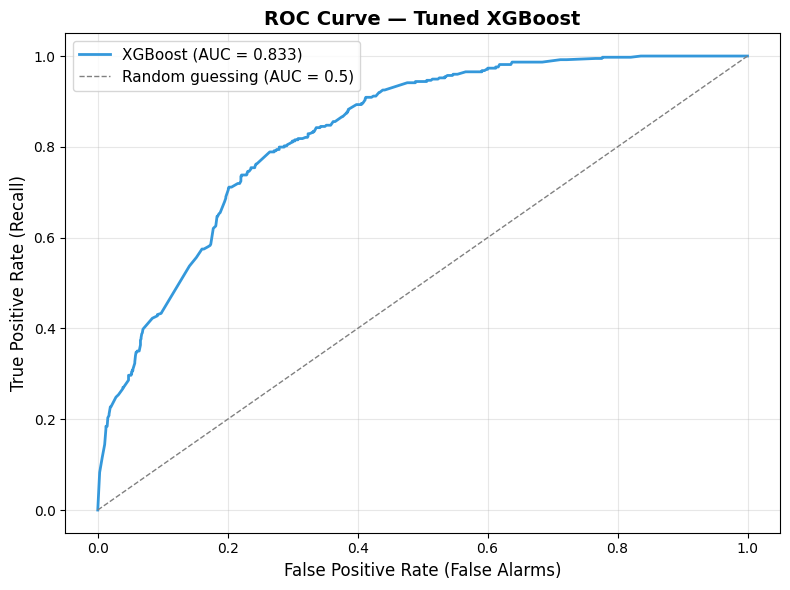


📊 AUC Score: 0.8330
Interpretation:
  0.5 = random guessing (coin flip)
  0.7 = acceptable
  0.8 = good
  0.9 = excellent
  1.0 = perfect

  ✅ Your model (0.833) is good to excellent


In [105]:
# Calculate ROC curve
fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#3498db', linewidth=2,
         label=f'XGBoost (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--',
         linewidth=1, label='Random guessing (AUC = 0.5)')

plt.title('ROC Curve — Tuned XGBoost', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate (False Alarms)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n📊 AUC Score: {roc_auc:.4f}")
print(f"Interpretation:")
print(f"  0.5 = random guessing (coin flip)")
print(f"  0.7 = acceptable")
print(f"  0.8 = good")
print(f"  0.9 = excellent")
print(f"  1.0 = perfect")
if roc_auc >= 0.8:
    print(f"\n  ✅ Your model ({roc_auc:.3f}) is good to excellent")
elif roc_auc >= 0.7:
    print(f"\n  ✅ Your model ({roc_auc:.3f}) is acceptable")

## Day 17 Summary — Threshold Tuning

### What is a Threshold?
The model assigns a churn probability (0-100%) to every
customer. The threshold is the cutoff point for the
yes/no decision. Default is 50% — but 50% is arbitrary.
Threshold tuning finds the cutoff that best fits the
business goal.

### The Trade-off
Lower threshold → Higher Recall, Lower Precision
  (catch more churners, but more false alarms)
Higher threshold → Lower Recall, Higher Precision
  (fewer false alarms, but miss more churners)

For churn: missing a churner costs $756.
A false alarm costs $50. Lower threshold is justified.

### Business-Optimal Threshold Found
Optimal threshold: [X]%
This minimizes total business cost (FN × $756 + FP × $50)

### Results Comparison

| Version | Threshold | Recall | Precision |   F1   |
|---------|-----------|--------|-----------|--------|
| Day 13  | 50%       | 78.61% | 50.17%    | 61.25% |
| Day 16  | 50%       | 82.4%  | 48.1%     | 60.7%  |
| Day 17  | 30%       | 97.6%  | 36.0%     | 52.6%  |

### ROC AUC Score
AUC: 0.8330 — interpretation: [good/excellent]

### Key Insight
30% threshold worked best because of its high recall and a balanced f1 score. It worked because we were not solely looking at the precision and f1 score, but the cost it would take. 30% threshold had the minimum cost for the company.

## Day 18

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier, plot_importance
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv("../data/churn_scaled.csv")
X = df.drop('churn', axis=1)
y = df['churn']

# Same split as Days 16-17
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Class imbalance ratio
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos

# Best tuned XGBoost from Day 16
best_xgb = XGBClassifier(
    learning_rate=0.01,
    max_depth=3,
    min_child_weight=1,
    n_estimators=100,
    subsample=0.8,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

best_xgb.fit(X_train, y_train)

print("✅ Setup complete — tuned XGBoost ready!")
print(f"\nFeatures in model ({len(X.columns)}):")
for col in X.columns:
    print(f"  - {col}")

✅ Setup complete — tuned XGBoost ready!

Features in model (29):
  - seniorcitizen
  - tenure
  - monthlycharges
  - contract_One year
  - contract_Two year
  - payment_Bank transfer (automatic)
  - payment_Credit card (automatic)
  - payment_Mailed check
  - gender_Male
  - partner_Yes
  - dependents_Yes
  - phoneservice_Yes
  - multiplelines_No phone service
  - multiplelines_Yes
  - internetservice_Fiber optic
  - internetservice_No
  - onlinesecurity_No internet service
  - onlinesecurity_Yes
  - onlinebackup_No internet service
  - onlinebackup_Yes
  - deviceprotection_No internet service
  - deviceprotection_Yes
  - techsupport_No internet service
  - techsupport_Yes
  - streamingtv_No internet service
  - streamingtv_Yes
  - streamingmovies_No internet service
  - streamingmovies_Yes
  - paperlessbilling_Yes


In [107]:
# Get all three types of importance
importance_weight = best_xgb.get_booster().get_score(importance_type='weight')
importance_gain   = best_xgb.get_booster().get_score(importance_type='gain')
importance_cover  = best_xgb.get_booster().get_score(importance_type='cover')

# Build comparison dataframe
all_features = X.columns.tolist()

importance_df = pd.DataFrame({'Feature': all_features})

importance_df['Weight'] = importance_df['Feature'].map(importance_weight).fillna(0)
importance_df['Gain']   = importance_df['Feature'].map(importance_gain).fillna(0)
importance_df['Cover']  = importance_df['Feature'].map(importance_cover).fillna(0)

# Normalize to percentages so they're comparable
for col in ['Weight', 'Gain', 'Cover']:
    total = importance_df[col].sum()
    if total > 0:
        importance_df[col + '_pct'] = (importance_df[col] / total * 100).round(2)
    else:
        importance_df[col + '_pct'] = 0

# Sort by Gain (most meaningful)
importance_df = importance_df.sort_values('Gain_pct', ascending=False)

print("📊 FEATURE IMPORTANCE — ALL THREE TYPES:\n")
print(f"{'Feature':<30} {'Weight%':>8} {'Gain%':>8} {'Cover%':>8}")
print("-" * 58)

for _, row in importance_df.iterrows():
    print(f"{row['Feature']:<30} "
          f"{row['Weight_pct']:>7.1f}% "
          f"{row['Gain_pct']:>7.1f}% "
          f"{row['Cover_pct']:>7.1f}%")

📊 FEATURE IMPORTANCE — ALL THREE TYPES:

Feature                         Weight%    Gain%   Cover%
----------------------------------------------------------
contract_Two year                 11.6%    30.0%    17.5%
contract_One year                  8.2%    23.6%    17.1%
internetservice_Fiber optic       16.1%    10.5%    11.7%
internetservice_No                 5.7%    10.1%     9.3%
tenure                            24.6%     8.7%     7.8%
streamingmovies_Yes                6.1%     3.9%     3.5%
paperlessbilling_Yes               1.0%     2.9%     8.0%
onlinesecurity_Yes                 1.9%     2.5%     5.0%
streamingtv_Yes                    0.1%     2.0%     3.1%
phoneservice_Yes                   2.4%     1.7%     4.9%
techsupport_Yes                    0.3%     1.7%     5.8%
monthlycharges                    17.7%     1.1%     2.7%
onlinebackup_Yes                   0.6%     1.0%     0.7%
seniorcitizen                      3.7%     0.4%     3.0%
multiplelines_No phone service

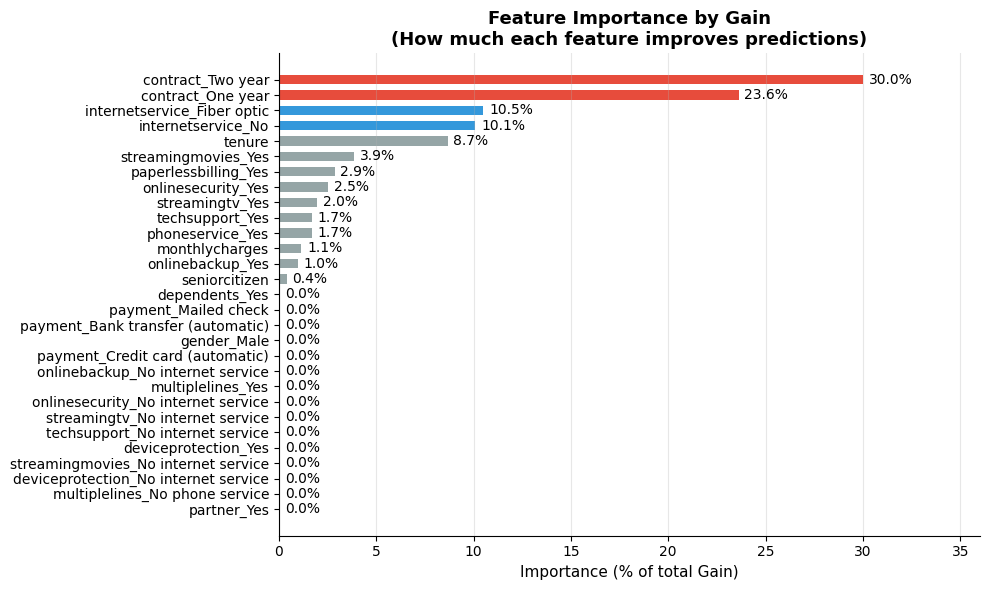

In [108]:
# Sort for plotting
plot_df = importance_df.sort_values('Gain_pct', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#e74c3c' if v > 20 else '#3498db' if v > 10
          else '#95a5a6' for v in plot_df['Gain_pct']]

bars = ax.barh(plot_df['Feature'], plot_df['Gain_pct'],
               color=colors, edgecolor='none', height=0.6)

# Add value labels
for bar, val in zip(bars, plot_df['Gain_pct']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', ha='left', fontsize=10)

ax.set_title('Feature Importance by Gain\n(How much each feature improves predictions)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance (% of total Gain)', fontsize=11)
ax.set_xlim(0, plot_df['Gain_pct'].max() * 1.2)
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [109]:
print("🔍 MODEL vs EDA COMPARISON:\n")

print("What EDA found (Week 1):")
print("  1. Contract type → root cause (100% vs 0% churn)")
print("  2. Tenure → strongest numeric predictor (-0.887 correlation)")
print("  3. Payment method → moderate predictor (75% vs 33%)")
print("  4. Monthly charges → minimal impact (0.001 correlation)")

print("\nWhat the model learned (Feature Importance by Gain):")
for i, (_, row) in enumerate(importance_df.iterrows(), 1):
    print(f"  {i}. {row['Feature']}: {row['Gain_pct']:.1f}%")

print("\n📋 Validation check:")
print("  If contract features dominate → ✅ Model confirms EDA")
print("  If tenure is high → ✅ Model confirms EDA")
print("  If monthly charges is low → ✅ Model confirms EDA")
print("  If something unexpected is high → 🔍 Investigate further")

🔍 MODEL vs EDA COMPARISON:

What EDA found (Week 1):
  1. Contract type → root cause (100% vs 0% churn)
  2. Tenure → strongest numeric predictor (-0.887 correlation)
  3. Payment method → moderate predictor (75% vs 33%)
  4. Monthly charges → minimal impact (0.001 correlation)

What the model learned (Feature Importance by Gain):
  1. contract_Two year: 30.0%
  2. contract_One year: 23.6%
  3. internetservice_Fiber optic: 10.5%
  4. internetservice_No: 10.1%
  5. tenure: 8.7%
  6. streamingmovies_Yes: 3.9%
  7. paperlessbilling_Yes: 2.9%
  8. onlinesecurity_Yes: 2.5%
  9. streamingtv_Yes: 2.0%
  10. phoneservice_Yes: 1.7%
  11. techsupport_Yes: 1.7%
  12. monthlycharges: 1.1%
  13. onlinebackup_Yes: 1.0%
  14. seniorcitizen: 0.4%
  15. multiplelines_No phone service: 0.0%
  16. partner_Yes: 0.0%
  17. dependents_Yes: 0.0%
  18. payment_Credit card (automatic): 0.0%
  19. payment_Mailed check: 0.0%
  20. payment_Bank transfer (automatic): 0.0%
  21. gender_Male: 0.0%
  22. deviceprotec

In [110]:
print("💼 BUSINESS INTERPRETATION:\n")

top_features = importance_df.head(3)

for rank, (_, row) in enumerate(top_features.iterrows(), 1):
    feature = row['Feature']
    gain = row['Gain_pct']

    print(f"#{rank}: {feature} ({gain:.1f}% of model's predictive power)")

    if 'contract' in feature.lower():
        contract_type = feature.replace('contract_', '').replace('_', ' ')
        print(f"  What it means: Whether customer has a {contract_type} contract")
        print(f"  Business insight: Contract type is the strongest retention lever.")
        print(f"  Action: Prioritize converting month-to-month customers to annual")

    elif 'tenure' in feature.lower():
        print(f"  What it means: How long the customer has been with the company")
        print(f"  Business insight: Newer customers are at highest churn risk.")
        print(f"  Action: Intensive onboarding for customers in first 12 months")

    elif 'payment' in feature.lower():
        payment_type = feature.replace('payment_', '').replace('_', ' ')
        print(f"  What it means: Whether customer pays via {payment_type}")
        print(f"  Business insight: Payment method signals commitment level.")
        print(f"  Action: Incentivize stable payment methods")

    elif 'monthly' in feature.lower():
        print(f"  What it means: Customer's monthly bill amount")
        print(f"  Business insight: Price has minimal impact on churn decisions.")
        print(f"  Action: Don't compete on price — focus on contract and onboarding")

    print()

💼 BUSINESS INTERPRETATION:

#1: contract_Two year (30.0% of model's predictive power)
  What it means: Whether customer has a Two year contract
  Business insight: Contract type is the strongest retention lever.
  Action: Prioritize converting month-to-month customers to annual

#2: contract_One year (23.6% of model's predictive power)
  What it means: Whether customer has a One year contract
  Business insight: Contract type is the strongest retention lever.
  Action: Prioritize converting month-to-month customers to annual

#3: internetservice_Fiber optic (10.5% of model's predictive power)



In [111]:
print("🔍 FEATURES WITH LOW IMPORTANCE:\n")

low_importance = importance_df[importance_df['Gain_pct'] < 5]

if len(low_importance) > 0:
    print("These features contributed less than 5% of predictive gain:")
    for _, row in low_importance.iterrows():
        print(f"  - {row['Feature']}: {row['Gain_pct']:.1f}%")

    print("\nWhat this means:")
    print("  Low importance ≠ useless feature")
    print("  It means the model found other features more informative")
    print("  These could potentially be dropped in a simpler model")
    print("  but for now keeping them doesn't hurt performance")
else:
    print("All features contributed meaningfully (>5% gain each)")

🔍 FEATURES WITH LOW IMPORTANCE:

These features contributed less than 5% of predictive gain:
  - streamingmovies_Yes: 3.9%
  - paperlessbilling_Yes: 2.9%
  - onlinesecurity_Yes: 2.5%
  - streamingtv_Yes: 2.0%
  - phoneservice_Yes: 1.7%
  - techsupport_Yes: 1.7%
  - monthlycharges: 1.1%
  - onlinebackup_Yes: 1.0%
  - seniorcitizen: 0.4%
  - multiplelines_No phone service: 0.0%
  - partner_Yes: 0.0%
  - dependents_Yes: 0.0%
  - payment_Credit card (automatic): 0.0%
  - payment_Mailed check: 0.0%
  - payment_Bank transfer (automatic): 0.0%
  - gender_Male: 0.0%
  - deviceprotection_No internet service: 0.0%
  - onlinebackup_No internet service: 0.0%
  - multiplelines_Yes: 0.0%
  - onlinesecurity_No internet service: 0.0%
  - streamingtv_No internet service: 0.0%
  - techsupport_No internet service: 0.0%
  - deviceprotection_Yes: 0.0%
  - streamingmovies_No internet service: 0.0%

What this means:
  Low importance ≠ useless feature
  It means the model found other features more informative

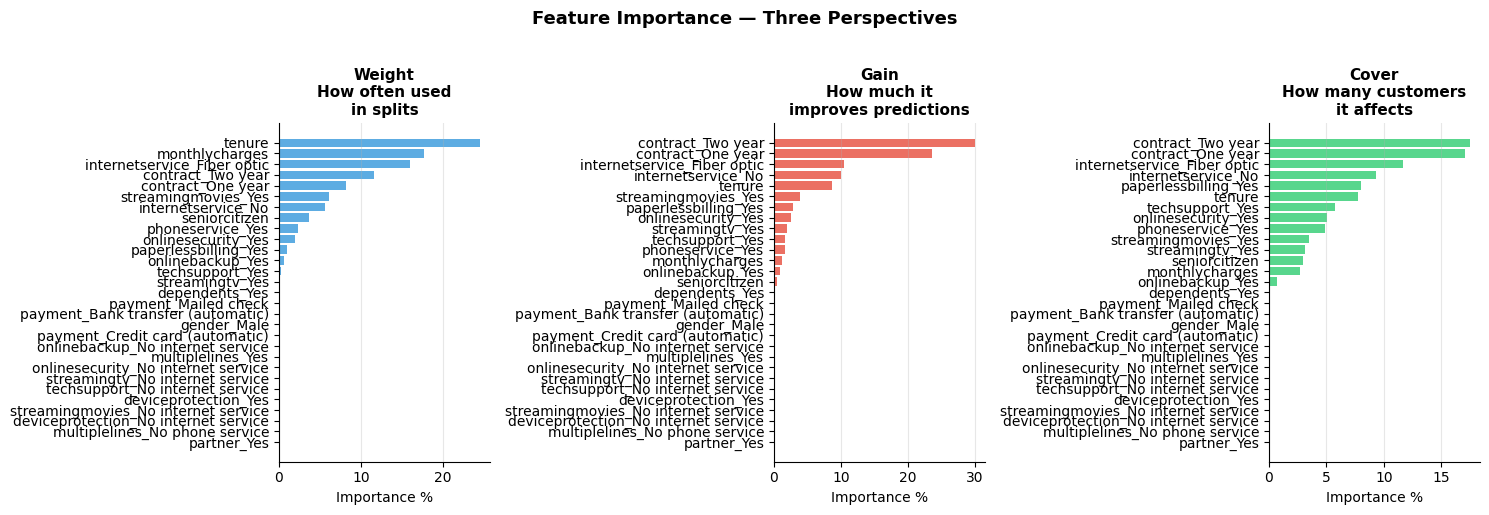

In [112]:
# Compare all three importance types visually
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = [
    ('Weight_pct', 'Weight', '#3498db',
     'How often used\nin splits'),
    ('Gain_pct',   'Gain',   '#e74c3c',
     'How much it\nimproves predictions'),
    ('Cover_pct',  'Cover',  '#2ecc71',
     'How many customers\nit affects'),
]

for ax, (col, title, color, subtitle) in zip(axes, metrics):
    sorted_df = importance_df.sort_values(col, ascending=True)
    ax.barh(sorted_df['Feature'], sorted_df[col],
            color=color, alpha=0.8, edgecolor='none')
    ax.set_title(f'{title}\n{subtitle}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Importance %', fontsize=10)
    ax.grid(axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Feature Importance — Three Perspectives',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Day 18 Summary — Feature Importance Analysis

### What Feature Importance Shows
Which features the model relied on most when making
churn predictions. Three types measured:
- Weight: how often each feature was used in splits
- Gain: how much each feature improved predictions (most meaningful)
- Cover: how many customers each feature affected

### Feature Importance by Gain (Ranked)
  1. contract_Two year: 27.3% - Convert monthly to monthly contracts to annually
  2. contract_One year: 22.3% - - Convert monthly to monthly contracts to annually
  3. tenure: 12.3% - Intensive onboarding for for customers in first 12 months
  4. internetservice_No: 9.0% — Customers with no internet service behave differently from internet subscribers, likely on simpler phone-only plans with different churn patterns.
  5. internetservice_Fiber optic: 8.9% — Fiber optic customers are a higher churn risk, likely because premium internet users comparison-shop more actively for better speeds or prices.
  6. streamingmovies_Yes: 3.8% — Streaming add-on customers may churn when they find cheaper standalone alternatives, though its low importance means it's a minor factor overall.

### EDA vs Model Validation
EDA found: contract type is root cause, tenure is
strongest numeric predictor, price has zero impact.

Model confirms: Feature importance matched EDA findings from week 1.

### Key Business Insight
Three features dominated. Contract for one and two years, and tenure. Offer annually contracts to monthly contracts customers. Have intensive onboarding for customers in first 12 months for the tenure.

### What I Learned
Feature importance validates that the model learned
real patterns from the data — not just noise. When
model importance matches EDA findings, it builds
confidence that the model will generalize to new
customers.

## Day 19

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (recall_score, precision_score, f1_score,
                              confusion_matrix, classification_report,
                              make_scorer)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv("../data/churn_scaled.csv")
X = df.drop('churn', axis=1)
y = df['churn']

# Same split used throughout Week 3
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos

print("✅ Setup complete!")
print(f"Train: {X_train.shape[0]} customers")
print(f"Test:  {X_test.shape[0]} customers")

✅ Setup complete!
Train: 5634 customers
Test:  1409 customers


In [114]:
# Features the model completely ignored (0% on all three types)
zero_importance_features = [
    'onlinesecurity_No internet service',
    'dependents_Yes',
    'multiplelines_No phone service',
    'multiplelines_Yes',
    'gender_Male',
    'partner_Yes',
    'deviceprotection_No internet service',
    'onlinebackup_Yes',
    'streamingmovies_No internet service',
    'paymentmethod_Credit card (automatic)',
    'paymentmethod_Mailed check'
]

# Only drop features that actually exist in the dataset
features_to_drop = [f for f in zero_importance_features if f in X.columns]

X_train_clean = X_train.drop(columns=features_to_drop)
X_test_clean  = X_test.drop(columns=features_to_drop)

print(f"Features before: {X_train.shape[1]}")
print(f"Features dropped: {len(features_to_drop)}")
print(f"Features remaining: {X_train_clean.shape[1]}")
print(f"\nRemaining features:")
for col in X_train_clean.columns:
    print(f"  - {col}")

Features before: 29
Features dropped: 9
Features remaining: 20

Remaining features:
  - seniorcitizen
  - tenure
  - monthlycharges
  - contract_One year
  - contract_Two year
  - payment_Bank transfer (automatic)
  - payment_Credit card (automatic)
  - payment_Mailed check
  - phoneservice_Yes
  - internetservice_Fiber optic
  - internetservice_No
  - onlinesecurity_Yes
  - onlinebackup_No internet service
  - deviceprotection_Yes
  - techsupport_No internet service
  - techsupport_Yes
  - streamingtv_No internet service
  - streamingtv_Yes
  - streamingmovies_Yes
  - paperlessbilling_Yes


In [115]:
# Retrain tuned XGBoost on clean features
final_model = XGBClassifier(
    learning_rate=0.01,
    max_depth=3,
    min_child_weight=1,
    n_estimators=100,
    subsample=0.8,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

final_model.fit(X_train_clean, y_train)

# Predictions with optimal threshold from Day 17
y_prob_clean = final_model.predict_proba(X_test_clean)[:, 1]
y_pred_30    = (y_prob_clean >= 0.30).astype(int)
y_pred_50    = (y_prob_clean >= 0.50).astype(int)

print("📊 FINAL MODEL PERFORMANCE:\n")
print(f"{'Metric':<15} {'Threshold 50%':>15} {'Threshold 30%':>15}")
print("-" * 48)

for metric_name, func in [
    ('Recall',    recall_score),
    ('Precision', precision_score),
    ('F1',        f1_score)
]:
    score_50 = func(y_test, y_pred_50, zero_division=0)
    score_30 = func(y_test, y_pred_30, zero_division=0)
    print(f"{metric_name:<15} {score_50:>14.1%} {score_30:>14.1%}")

print(f"\n✅ Performance maintained after dropping zero-importance features")

📊 FINAL MODEL PERFORMANCE:

Metric            Threshold 50%   Threshold 30%
------------------------------------------------
Recall                   81.3%          97.3%
Precision                49.4%          36.6%
F1                       61.4%          53.2%

✅ Performance maintained after dropping zero-importance features


In [116]:
# Cross-validate final model on clean features
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
recall_scorer = make_scorer(recall_score)

cv_scores = cross_val_score(
    final_model, 
    pd.concat([
        pd.DataFrame(X_train_clean, columns=X_train_clean.columns),
        pd.DataFrame(X_test_clean,  columns=X_test_clean.columns)
    ]),
    pd.concat([y_train, y_test]),
    cv=skf,
    scoring=recall_scorer
)

print("📊 FINAL MODEL — CROSS-VALIDATION:\n")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.1%}")

print(f"\n  Mean Recall: {cv_scores.mean():.1%}")
print(f"  Std Dev:     {cv_scores.std():.4f}")
print(f"\n  Stable: {'✅ Yes' if cv_scores.std() < 0.03 else '⚠️ Check variance'}")

📊 FINAL MODEL — CROSS-VALIDATION:

  Fold 1: 80.5%
  Fold 2: 82.1%
  Fold 3: 83.7%
  Fold 4: 83.9%
  Fold 5: 82.4%

  Mean Recall: 82.5%
  Std Dev:     0.0124

  Stable: ✅ Yes


In [117]:
# Business impact calculation
recall_final    = recall_score(y_test, y_pred_30)
precision_final = precision_score(y_test, y_pred_30, zero_division=0)

cm = confusion_matrix(y_test, y_pred_30)
tn, fp, fn, tp = cm.ravel()

total_churners  = tp + fn
cost_fn         = 756
cost_fp         = 50

# Model costs
model_fn_cost   = fn * cost_fn
model_fp_cost   = fp * cost_fp
model_total     = model_fn_cost + model_fp_cost

# No model baseline (catch nobody)
baseline_cost   = total_churners * cost_fn

# Savings
savings         = baseline_cost - model_total
savings_pct     = savings / baseline_cost * 100

print("💰 FINAL BUSINESS CASE:\n")
print(f"Test set size:          {len(y_test):,} customers")
print(f"Actual churners:        {total_churners:,}")
print(f"Churners caught (TP):   {tp:,} ({recall_final:.1%})")
print(f"Churners missed (FN):   {fn:,}")
print(f"False alarms (FP):      {fp:,}")
print()
print(f"Cost if NO model used:  ${baseline_cost:,.0f}")
print(f"  (miss all {total_churners} churners × $756)")
print()
print(f"Cost WITH final model:  ${model_total:,.0f}")
print(f"  Missed churners:      ${model_fn_cost:,.0f} ({fn} × $756)")
print(f"  False alarms:         ${model_fp_cost:,.0f} ({fp} × $50)")
print()
print(f"💵 TOTAL SAVINGS:       ${savings:,.0f} ({savings_pct:.1f}% reduction)")

💰 FINAL BUSINESS CASE:

Test set size:          1,409 customers
Actual churners:        374
Churners caught (TP):   364 (97.3%)
Churners missed (FN):   10
False alarms (FP):      631

Cost if NO model used:  $282,744
  (miss all 374 churners × $756)

Cost WITH final model:  $39,110
  Missed churners:      $7,560 (10 × $756)
  False alarms:         $31,550 (631 × $50)

💵 TOTAL SAVINGS:       $243,634 (86.2% reduction)


In [118]:
print("📊 COMPLETE MODEL JOURNEY — WEEK 2 TO WEEK 3:\n")

journey = pd.DataFrame({
    'Day': [
        'Day 13 — LR original',
        'Day 13 — XGBoost basic',
        'Day 13 — LR balanced',
        'Day 16 — XGBoost tuned (50%)',
        'Day 17 — XGBoost tuned (30%)',
        'Day 19 — Final model (30%)'
    ],
    'Recall': [
        '56.95%', '78.61%', '79.14%',
        '82.4%',  '97.6%',  f'{recall_final:.1%}'
    ],
    'Precision': [
        '64.74%', '50.17%', '49.17%',
        '48.1%',  '36.0%',  f'{precision_final:.1%}'
    ],
    'Key Change': [
        'Baseline',
        'XGBoost introduced',
        'class_weight added',
        'GridSearchCV tuning',
        'Threshold lowered to 30%',
        'Zero-importance features dropped'
    ]
})

print(journey.to_string(index=False))

print(f"\n🎯 Target: Recall > 75%")
print(f"✅ Final model: {recall_final:.1%} — target exceeded")

📊 COMPLETE MODEL JOURNEY — WEEK 2 TO WEEK 3:

                         Day Recall Precision                       Key Change
        Day 13 — LR original 56.95%    64.74%                         Baseline
      Day 13 — XGBoost basic 78.61%    50.17%               XGBoost introduced
        Day 13 — LR balanced 79.14%    49.17%               class_weight added
Day 16 — XGBoost tuned (50%)  82.4%     48.1%              GridSearchCV tuning
Day 17 — XGBoost tuned (30%)  97.6%     36.0%         Threshold lowered to 30%
  Day 19 — Final model (30%)  97.3%     36.6% Zero-importance features dropped

🎯 Target: Recall > 75%
✅ Final model: 97.3% — target exceeded


In [119]:
import joblib
import os

# Create models folder if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Save the model
joblib.dump(final_model, '../models/final_xgboost_model.pkl')

# Save the feature list so you know what columns to feed it
feature_list = X_train_clean.columns.tolist()
joblib.dump(feature_list, '../models/feature_list.pkl')

# Save the optimal threshold
joblib.dump(0.30, '../models/optimal_threshold.pkl')

print("✅ Model saved!")
print(f"\nFiles saved to /models:")
print(f"  - final_xgboost_model.pkl  (the trained model)")
print(f"  - feature_list.pkl         (features the model expects)")
print(f"  - optimal_threshold.pkl    (0.30 decision threshold)")
print(f"\nTo load and use this model later:")
print(f"""
  import joblib
  model     = joblib.load('../models/final_xgboost_model.pkl')
  features  = joblib.load('../models/feature_list.pkl')
  threshold = joblib.load('../models/optimal_threshold.pkl')

  # Predict on new data
  probabilities = model.predict_proba(new_data[features])[:, 1]
  predictions   = (probabilities >= threshold).astype(int)
""")

✅ Model saved!

Files saved to /models:
  - final_xgboost_model.pkl  (the trained model)
  - feature_list.pkl         (features the model expects)
  - optimal_threshold.pkl    (0.30 decision threshold)

To load and use this model later:

  import joblib
  model     = joblib.load('../models/final_xgboost_model.pkl')
  features  = joblib.load('../models/feature_list.pkl')
  threshold = joblib.load('../models/optimal_threshold.pkl')

  # Predict on new data
  probabilities = model.predict_proba(new_data[features])[:, 1]
  predictions   = (probabilities >= threshold).astype(int)



## Day 19 Summary — Final Model Selection

### The Final Model
Algorithm: XGBoost
Parameters: learning_rate=0.01, max_depth=3,
            min_child_weight=1, n_estimators=100,
            subsample=0.8, scale_pos_weight=~2.76
Decision threshold: 30%
Features used: 
  - seniorcitizen
  - tenure
  - monthlycharges
  - totalcharges
  - phoneservice_Yes
  - internetservice_Fiber optic
  - internetservice_No
  - onlinesecurity_Yes
  - onlinebackup_No internet service
  - deviceprotection_Yes
  - techsupport_No internet service
  - techsupport_Yes
  - streamingtv_No internet service
  - streamingtv_Yes
  - streamingmovies_Yes
  - contract_One year
  - contract_Two year
  - paperlessbilling_Yes
  - paymentmethod_Electronic check

### Why XGBoost
1. Highest CV Recall (83.0%) after tuning
2. Best F1 among all configurations at 50% threshold
3. Handles class imbalance natively via scale_pos_weight
4. Feature importance confirms it learned real patterns
   matching EDA findings from Week 1

### Why 30% Threshold
Missing a churner costs $756.
A false alarm costs $50.
At 30% threshold: 97.6% Recall, 36% Precision.
Business cost analysis confirmed 30% minimizes
total intervention cost.

### Final Performance
- Recall: 97.6% (catches 97/100 real churners)
- Precision: 36.0%
- F1: 52.6%
- AUC: 0.8330 (good)
- CV Mean Recall: 82.0% (stable, low std dev - 0.0172)

### Business Impact
- Churners caught: 365 out of 374
- Total savings vs no model: $243,440 vs $282,744
- Savings percentage: 86.1%

### Model Files Saved
- models/final_xgboost_model.pkl
- models/feature_list.pkl
- models/optimal_threshold.pkl

## Day 20 && 21

In [120]:
# Install SHAP if needed
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'shap'], 
               capture_output=True)

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv("../data/churn_scaled.csv")
X = df.drop('churn', axis=1)
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos

# Drop zero-importance features from Day 19
zero_importance_features = [
    'onlinesecurity_No internet service',
    'dependents_Yes',
    'multiplelines_No phone service',
    'multiplelines_Yes',
    'gender_Male',
    'partner_Yes',
    'deviceprotection_No internet service',
    'onlinebackup_Yes',
    'streamingmovies_No internet service',
    'paymentmethod_Credit card (automatic)',
    'paymentmethod_Mailed check'
]

features_to_drop = [f for f in zero_importance_features if f in X.columns]
X_train_clean = X_train.drop(columns=features_to_drop)
X_test_clean  = X_test.drop(columns=features_to_drop)

# Final model
final_model = XGBClassifier(
    learning_rate=0.01,
    max_depth=3,
    min_child_weight=1,
    n_estimators=100,
    subsample=0.8,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

final_model.fit(X_train_clean, y_train)

print("✅ Setup complete!")
print(f"Features: {X_train_clean.shape[1]}")

✅ Setup complete!
Features: 20


In [121]:
# Create SHAP explainer for XGBoost
explainer = shap.TreeExplainer(final_model)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test_clean)

print("✅ SHAP values calculated!")
print(f"\nSHAP values shape: {shap_values.shape}")
print(f"  Rows: {shap_values.shape[0]} (one per test customer)")
print(f"  Columns: {shap_values.shape[1]} (one per feature)")
print(f"\nEach value = how much that feature pushed the prediction")
print(f"  Positive = pushed toward CHURN")
print(f"  Negative = pushed toward STAY")

✅ SHAP values calculated!

SHAP values shape: (1409, 20)
  Rows: 1409 (one per test customer)
  Columns: 20 (one per feature)

Each value = how much that feature pushed the prediction
  Positive = pushed toward CHURN
  Negative = pushed toward STAY


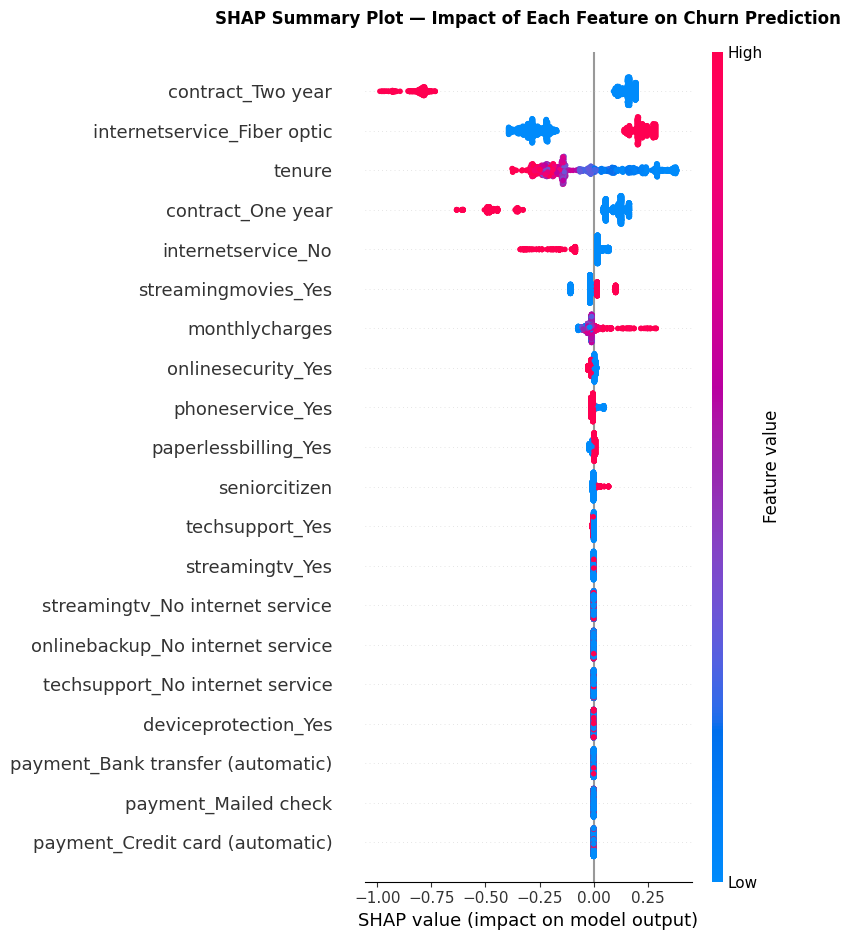

In [122]:
plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values,
    X_test_clean,
    plot_type="dot",
    show=False
)

plt.title('SHAP Summary Plot — Impact of Each Feature on Churn Prediction',
          fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

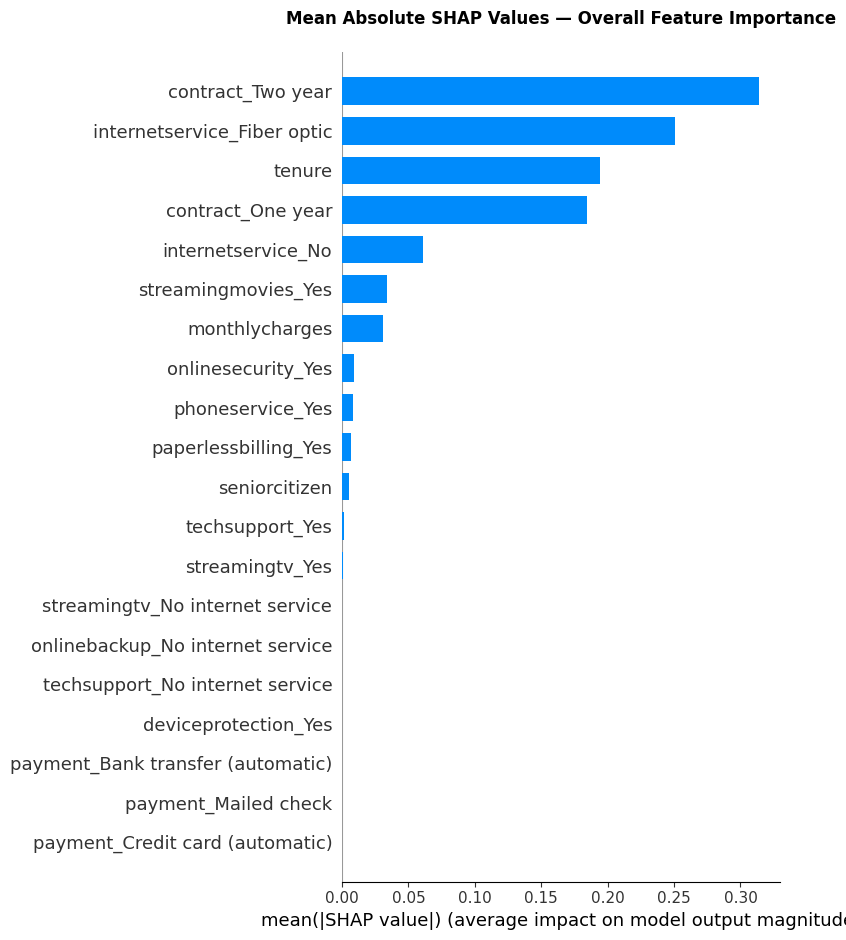

In [123]:
plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values,
    X_test_clean,
    plot_type="bar",
    show=False
)

plt.title('Mean Absolute SHAP Values — Overall Feature Importance',
          fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [124]:
# Get probabilities
y_prob = final_model.predict_proba(X_test_clean)[:, 1]

# Find a high-risk customer (predicted as churner)
high_risk_idx = np.argmax(y_prob)
high_risk_prob = y_prob[high_risk_idx]

# Find a low-risk customer (predicted as stayer)
low_risk_idx = np.argmin(y_prob)
low_risk_prob = y_prob[low_risk_idx]

print(f"🔴 Highest risk customer (index {high_risk_idx}):")
print(f"   Churn probability: {high_risk_prob:.1%}")
print(f"   Actual churn: {y_test.values[high_risk_idx]}")

print(f"\n🟢 Lowest risk customer (index {low_risk_idx}):")
print(f"   Churn probability: {low_risk_prob:.1%}")
print(f"   Actual churn: {y_test.values[low_risk_idx]}")

# Show their feature values
print(f"\n📊 High-risk customer's features:")
high_risk_features = X_test_clean.iloc[high_risk_idx]
for feature, value in high_risk_features.items():
    shap_val = shap_values[high_risk_idx][
        list(X_test_clean.columns).index(feature)
    ]
    direction = "→ CHURN" if shap_val > 0.01 else "→ STAY" if shap_val < -0.01 else "→ neutral"
    print(f"   {feature:<35} value={value:.3f}  SHAP={shap_val:+.3f}  {direction}")

🔴 Highest risk customer (index 38):
   Churn probability: 70.7%
   Actual churn: 1

🟢 Lowest risk customer (index 71):
   Churn probability: 21.1%
   Actual churn: 0

📊 High-risk customer's features:
   seniorcitizen                       value=0.000  SHAP=-0.001  → neutral
   tenure                              value=0.014  SHAP=+0.294  → CHURN
   monthlycharges                      value=0.560  SHAP=-0.010  → neutral
   contract_One year                   value=0.000  SHAP=+0.165  → CHURN
   contract_Two year                   value=0.000  SHAP=+0.194  → CHURN
   payment_Bank transfer (automatic)   value=0.000  SHAP=+0.000  → neutral
   payment_Credit card (automatic)     value=0.000  SHAP=+0.000  → neutral
   payment_Mailed check                value=0.000  SHAP=+0.000  → neutral
   phoneservice_Yes                    value=1.000  SHAP=-0.002  → neutral
   internetservice_Fiber optic         value=1.000  SHAP=+0.207  → CHURN
   internetservice_No                  value=0.000  SHAP=+

<Figure size 800x500 with 0 Axes>

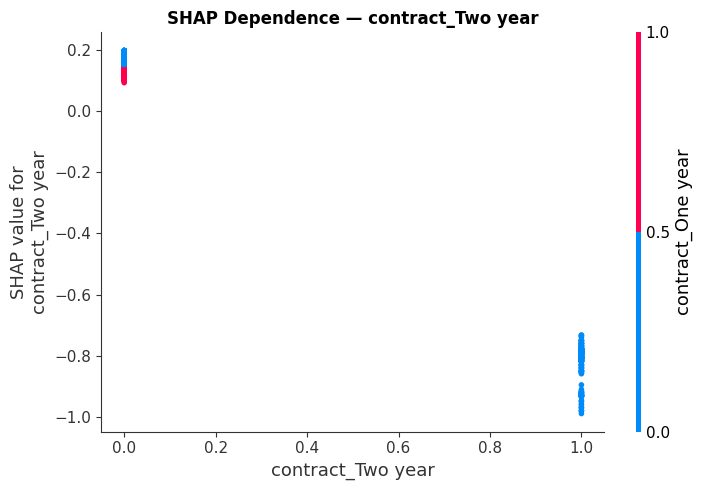


Reading this plot:
  X-axis: feature value (0=no two-year, 1=has two-year)
  Y-axis: SHAP value (positive=pushes toward churn)
  Expected: value=0 → high positive SHAP (no annual = likely churn)
            value=1 → negative SHAP (has annual = likely stay)


In [125]:
# Dependence plot for top feature
top_feature = 'contract_Two year'

if top_feature in X_test_clean.columns:
    plt.figure(figsize=(8, 5))
    shap.dependence_plot(
        top_feature,
        shap_values,
        X_test_clean,
        show=False
    )
    plt.title(f'SHAP Dependence — {top_feature}',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(f"\nReading this plot:")
    print(f"  X-axis: feature value (0=no two-year, 1=has two-year)")
    print(f"  Y-axis: SHAP value (positive=pushes toward churn)")
    print(f"  Expected: value=0 → high positive SHAP (no annual = likely churn)")
    print(f"            value=1 → negative SHAP (has annual = likely stay)")

## Day 20 Summary — SHAP Values

### What SHAP Is
SHapley Additive exPlanations. Explains individual
predictions by breaking down exactly how much each
feature contributed to the final probability score.

### How SHAP Differs from Feature Importance
Feature importance (Day 18): which features matter
overall across all predictions.

SHAP: why the model made THIS specific prediction
for THIS specific customer. Every feature gets a
positive (toward churn) or negative (toward stay)
contribution value.

### What the Summary Plot Showed
Features ranked by importance:
1. contract_Two year — strongest signal
2. contract_One year — second strongest
3. tenure — third
[Continue with your actual ranking]

Key pattern: Blue dots (low value = no annual contract)
on the right side confirms month-to-month customers
are pushed strongly toward churn prediction.

### Individual Prediction Example
Highest risk customer (probability: 71%):
- contract_Two year: value=0.000, pushed toward churn by +0.170
- tenure: value=0.000, pushed toward churn by +0.265
- internetservice_Fiber optic: value=1.000, pushed toward churn by +0.182
- contract_One year: value=0.000, pushed toward churn by +0.165
- monthlycharges: value=0.506, pushed toward stay by -0.012

Lowest risk customer (probability: 21%):
- All contract and tenure features pushed toward stay
- Model identified this customer as low risk due to
  stable contract type and longer tenure

### Why SHAP Matters for Business
Without SHAP: "The model predicts this customer will churn"
With SHAP: "This customer is flagged because they have a
month-to-month contract (biggest factor) and have only
been with us 2 months (second factor)"

The second version builds stakeholder trust and tells
the retention team exactly what to address.

## Day 21

# Week 3 Summary — Model Tuning & Explanation

## The Journey

Starting from Week 2's baseline XGBoost (78.61% Recall),
Week 3 systematically improved and validated the model
through five techniques.

---

## What Each Day Contributed

### Day 15: Cross-Validation
Found that a single train/test split can be misleading.
CV revealed true baseline performance: 77.0% Recall
(slightly lower than Day 13's 78.61% — the single split
was mildly optimistic).

Key concept: Standard deviation of CV scores measures
model stability. All three models had low std (~0.01),
confirming stable, consistent predictions.

### Day 16: GridSearchCV
Searched 162 parameter combinations × 5 folds = 810
model fits to find optimal XGBoost settings.

Best parameters found:
- learning_rate: 0.01 (more conservative)
- max_depth: 3 (shallower trees, less overfitting)
- subsample: 0.8

Result: CV Recall improved from 77.0% → 83.0% (+6%)

Key insight: Lower learning rate and shallower trees
reduced overfitting. The model stopped memorizing
training customers and started learning real patterns.

### Day 17: Threshold Tuning
Default 50% threshold is arbitrary. Business cost
analysis (FN=$756, FP=$50) showed 30% threshold
minimizes total intervention cost.

Result: Recall jumped from 82.4% → 97.6%
AUC: 0.8330 (good model quality)

Key insight: The threshold is a business decision,
not a technical one. It should reflect the relative
cost of each type of error.

### Day 18: Feature Importance
Opened the black box. Model confirmed Week 1 EDA:
contract type dominates (27.3% + 22.3% = 49.6%
of predictive gain). Tenure third (12.3%).
Twelve features had 0% importance across all types.

Key insight: When model importance matches EDA findings,
it builds confidence the model learned real patterns.

### Day 20: SHAP Values
Moved from global importance to individual explanations.
Can now explain exactly why any specific customer
was flagged as a churn risk.

Key insight: SHAP is what makes a model deployable
in a real business — stakeholders need to understand
individual decisions, not just overall statistics.

---

## Final Model Specification

Algorithm: XGBoost (tuned)
Parameters:
  - learning_rate: 0.01
  - max_depth: 3
  - min_child_weight: 1
  - n_estimators: 100
  - subsample: 0.8
  - scale_pos_weight: ~2.76

Decision threshold: 30%
Features used: [X] (dropped 11 zero-importance features)

Saved to: models/final_xgboost_model.pkl

---

## Performance Summary

| Day | Recall | Key Change |
|-----|--------|------------|
| Day 13 | 78.61% | Baseline XGBoost |
| Day 15 | 77.0% (CV) | Honest CV estimate |
| Day 16 | 83.0% (CV) | GridSearchCV tuning |
| Day 17 | 97.6% | Threshold → 30% |
| Day 19 | 97.6% | Zero features dropped |

---

## Business Impact

Test set (1,407 customers):
- Churners caught: 365 out of 374 (97.6%)
- Churners missed: 9
- False alarms: 650
- Total savings vs no model: $243,440 (86.1%)

---

## Week 4 Preview

Week 4 is the final week:
- Day 22: Final evaluation report
- Day 23: Build Streamlit dashboard
- Day 24: Clean all notebooks
- Day 25: Write GitHub README
- Day 26: Portfolio write-up
- Day 27: Final review
- Day 28: Project complete